## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в банку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, f1_score, recall_score, precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import lightgbm as lgb
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import shap

from utils import (value_counts_of_column, describe_columns_summary,
                   calculate_iqr_bounds, analyze_numeric_vs_target,
                   analyze_categorical_vs_target)

from process_bank_marketing import engineer_features, prepare_train_val

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

---
## 1. Exploratory Data Analysis

Знайомимося з даними, перевіряємо якість, аналізуємо кожну ознаку окремо та висуваємо гіпотези.

### 1.1 Завантаження та перевірка якості даних

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print('Shape (initial):', df.shape)
df.head()

Shape (initial): (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# describe_columns_summary: швидкий огляд типів, унікальних значень та прикладів
describe_columns_summary(df)

column               | dtype      | unique | missing | examples
-----------------------------------------------------------------------------------------------
age                  | int64      |     78 |       0 | [56, 57, 37, 40, 45]
job                  | object     |     12 |       0 | [housemaid, services, admin., blue-collar, technician]
marital              | object     |      4 |       0 | [married, single, divorced, unknown]
education            | object     |      8 |       0 | [basic.4y, high.school, basic.6y, basic.9y, professional.course]
default              | object     |      3 |       0 | [no, unknown, yes]
housing              | object     |      3 |       0 | [no, yes, unknown]
loan                 | object     |      3 |       0 | [no, yes, unknown]
contact              | object     |      2 |       0 | [telephone, cellular]
month                | object     |     10 |       0 | [may, jun, jul, aug, oct]
day_of_week          | object     |      5 |       0 | [mon, t

In [4]:
#Перевірка дублікатів та видалення
dupes = df.duplicated().sum()
print(f'Дублікатів: {dupes}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape після видалення дублікатів: {df.shape}')

Дублікатів: 12
Shape після видалення дублікатів: (41176, 21)


**Спостереження:** Явних пропущених значень немає, але деякі категоріальні ознаки містять значення `unknown` — це фактичні пропуски. Їх залишаємо як окрему категорію, щоб модель могла врахувати цей факт.

### 1.2 Аналіз цільової змінної

In [5]:
value_counts_of_column(df, 'y', n=2)

______Підрахунок значень колонки 'y'______

Топ 2 значень:

Значення        |  Кількість | Відсоток
------------------------------------------
no              |      36537 |   88.73%
yes             |       4639 |   11.27%



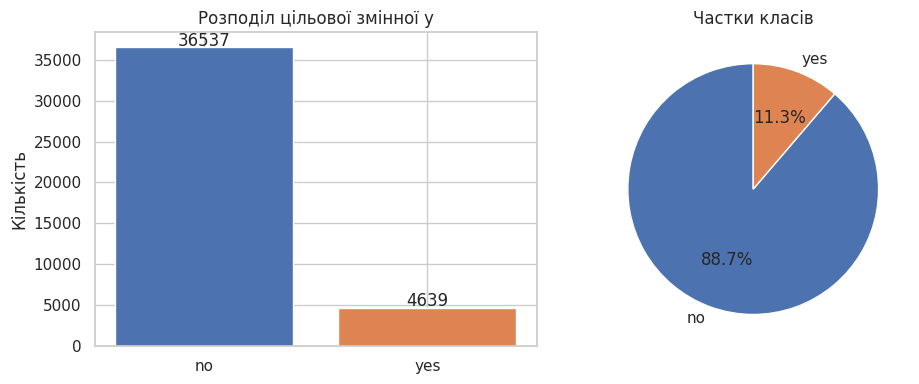

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df['y'].value_counts()

axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Розподіл цільової змінної y')
axes[0].set_ylabel('Кількість')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Частки класів')

plt.tight_layout()
plt.show()

**Спостереження**:
  сильний дисбаланс (88.7% vs 11.3%). Accuracy в якості метрики нам не підійде

### 1.3 Аналіз числових ознак

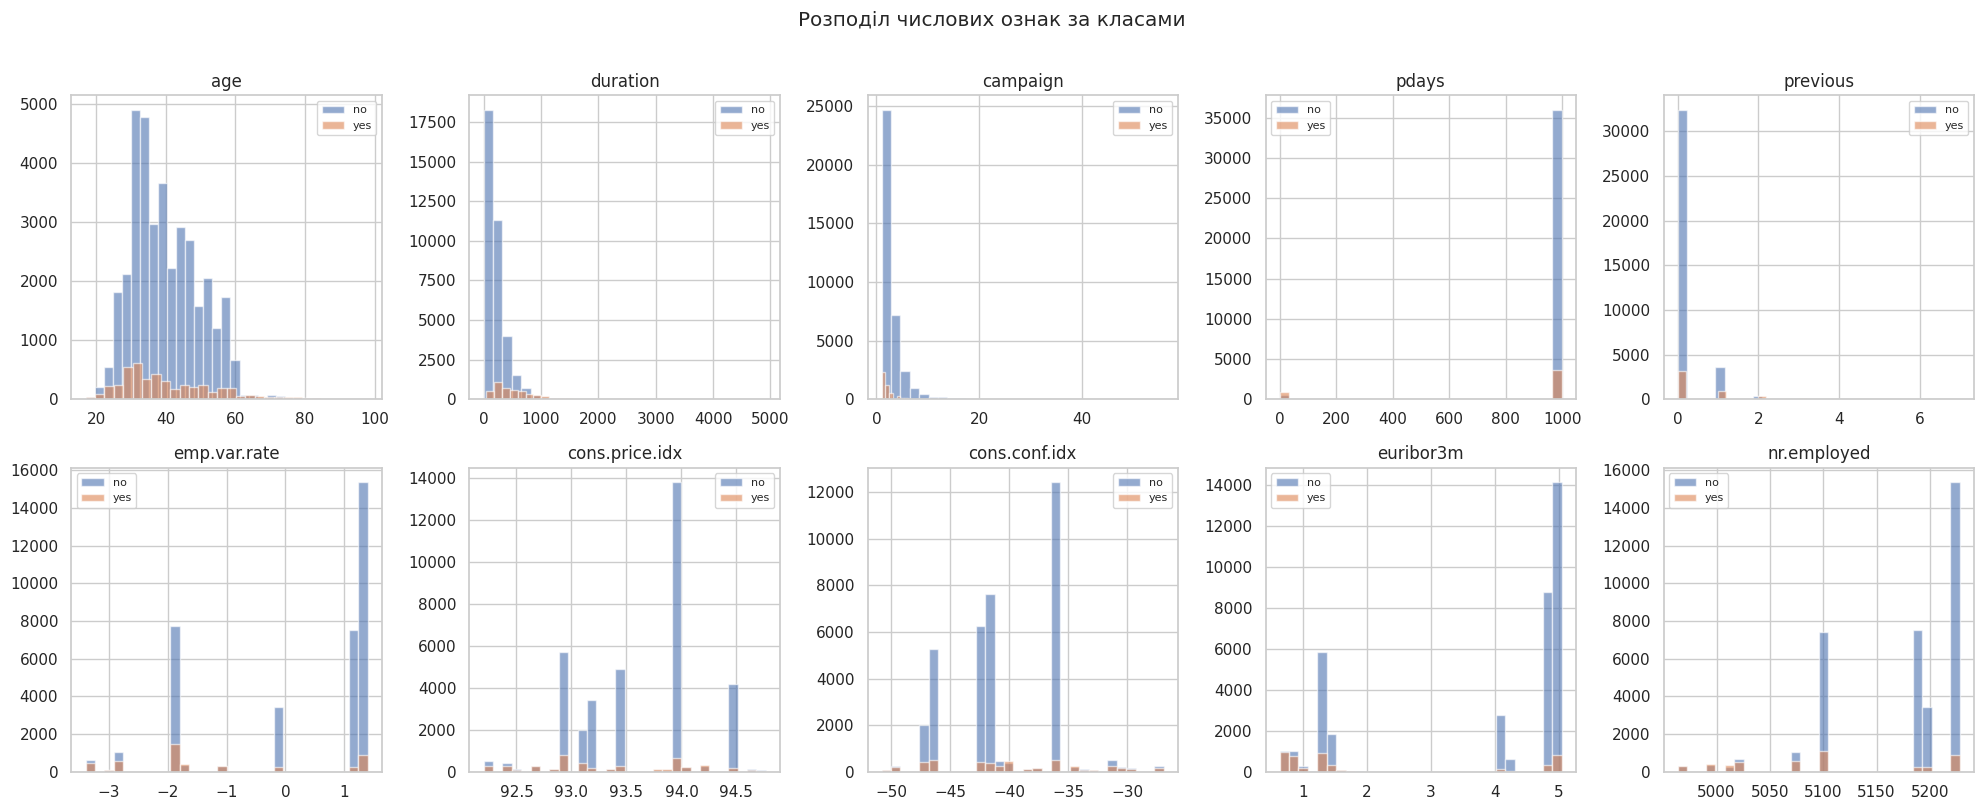

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.flat, num_cols):
    df[df['y']=='no'][col].hist(ax=ax, alpha=0.6, label='no', bins=30, color='#4C72B0')
    df[df['y']=='yes'][col].hist(ax=ax, alpha=0.6, label='yes', bins=30, color='#DD8452')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Розподіл числових ознак за класами', y=1.01)
plt.tight_layout()
plt.show()

Кореляція кожної числової ознаки з таргетом - це основа для вибору колонок для детального аналізу

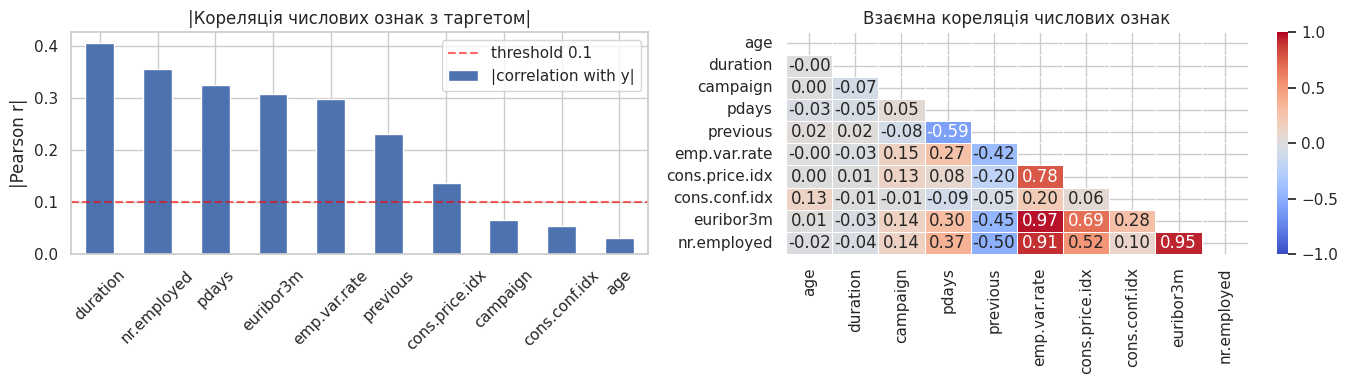

duration          0.405297
nr.employed       0.354669
pdays             0.324948
euribor3m         0.307740
emp.var.rate      0.298289
previous          0.230202
cons.price.idx    0.136134
campaign          0.066361
cons.conf.idx     0.054802
age               0.030381


In [8]:
y_num = (df['y'] == 'yes').astype(int)
corr_with_target = (
    df[num_cols]
    .corrwith(y_num)
    .abs()
    .sort_values(ascending=False)
    .rename('|correlation with y|')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: абсолютна кореляція з таргетом
corr_with_target.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].axhline(0.1, color='red', linestyle='--', alpha=0.6, label='threshold 0.1')
axes[0].set_title('|Кореляція числових ознак з таргетом|')
axes[0].set_ylabel('|Pearson r|')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Heatmap: взаємна кореляція числових ознак (мультиколінеарність)
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.4, ax=axes[1])
axes[1].set_title('Взаємна кореляція числових ознак')

plt.tight_layout()
plt.show()

print(corr_with_target.to_string())

**Висновки з кореляційного аналізу:**

**Сильна кореляція з таргетом (|r| > 0.1):**
- `euribor3m`, `emp.var.rate`, `nr.employed` - три найсильніші предиктори, але між собою корелюють на r > 0.9 (мультиколінеарність). Для детального аналізу достатньо **одного представника** - обираємо `euribor3m`, бо він щоденний (більше унікальних значень) і має найвищу кореляцію з таргетом.
- `campaign` — негативна кореляція: більше дзвінків → менше конверсій. Також має значимі outliers — варто розглянути детально.

**Слабка кореляція (|r| < 0.1):**
- `cons.price.idx`, `cons.conf.idx` - слабкі предиктори окремо, можуть бути корисними лише у взаємодії з іншими ознаками.
- `pdays`, `previous` - перетворюємо на `contacted_before`, числовий аналіз не актуальний.

Пропоную також розглянути **`age`** - Кореляція Пірсона (~0.03) не відображає U-подібну залежність (немає лінійного зв'язку, але є нелінійний). Саме тому `age` потребує binning-аналізу — щоб виявити нелінійний патерн.

#### Детальний аналіз ключових числових ознак

Для ознак, що показали найкращий розподіл між класами в EDA, викликаємо `analyze_numeric_vs_target()` з `utils.py` — отримуємо IQR/outlier звіт, кореляцію з таргетом, статистику по класах і три графіки.

------------------------------------------
  Аналіз: euribor3m
------------------------------------------

Загальна статистика:
count    41176.000000
mean         3.621293
std          1.734437
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000

IQR: 3.62
Outlier bounds: [-4.08, 10.39]
Outliers: 0 (0.00%)

Кореляція з таргетом: -0.308

Статистика по класах:
      mean  median    std
y                        
no   3.811   4.857  1.638
yes  2.123   1.266  1.743


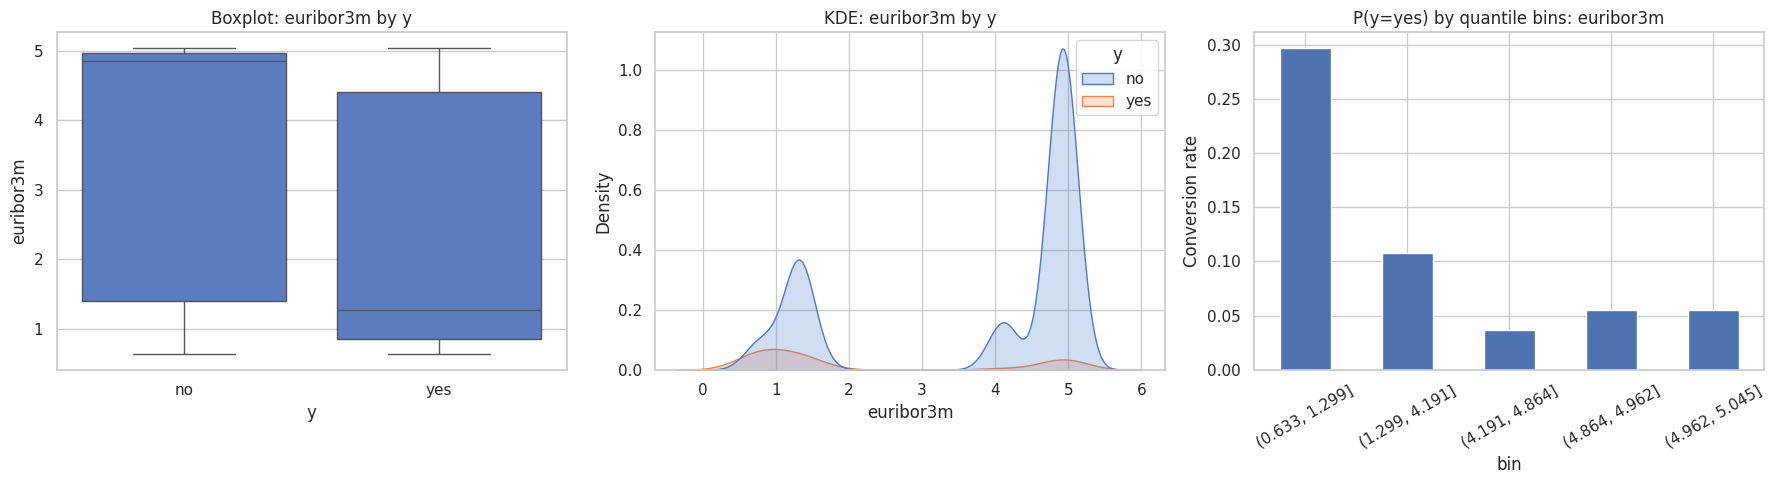

In [9]:
analyze_numeric_vs_target(df, 'euribor3m')

------------------------------------------
  Аналіз: campaign
------------------------------------------

Загальна статистика:
count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000

IQR: 2.00
Outlier bounds: [-2.00, 6.00]
Outliers: 2406 (5.84%)

Кореляція з таргетом: -0.066

Статистика по класах:
      mean  median    std
y                        
no   2.633     2.0  2.874
yes  2.052     2.0  1.666


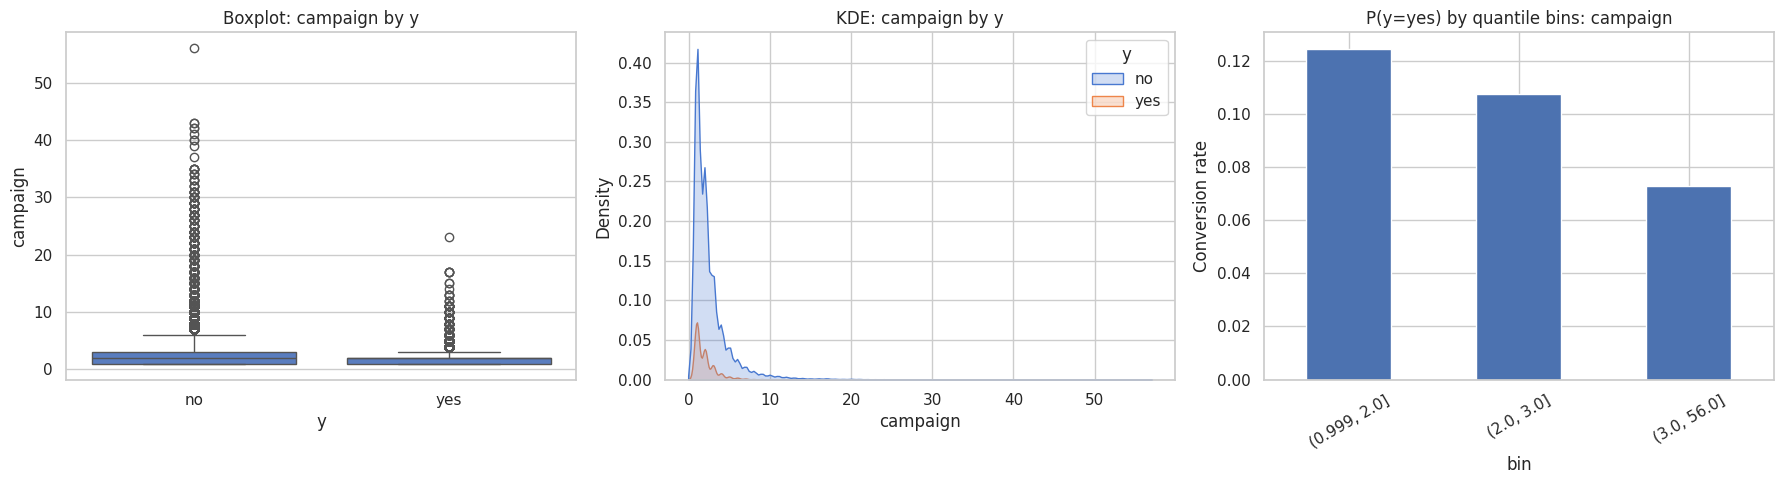

In [10]:
analyze_numeric_vs_target(df, 'campaign')

------------------------------------------
  Аналіз: age
------------------------------------------

Загальна статистика:
count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000

IQR: 15.00
Outlier bounds: [9.50, 69.50]
Outliers: 468 (1.14%)

Кореляція з таргетом: 0.030

Статистика по класах:
       mean  median     std
y                          
no   39.911    38.0   9.897
yes  40.912    37.0  13.839


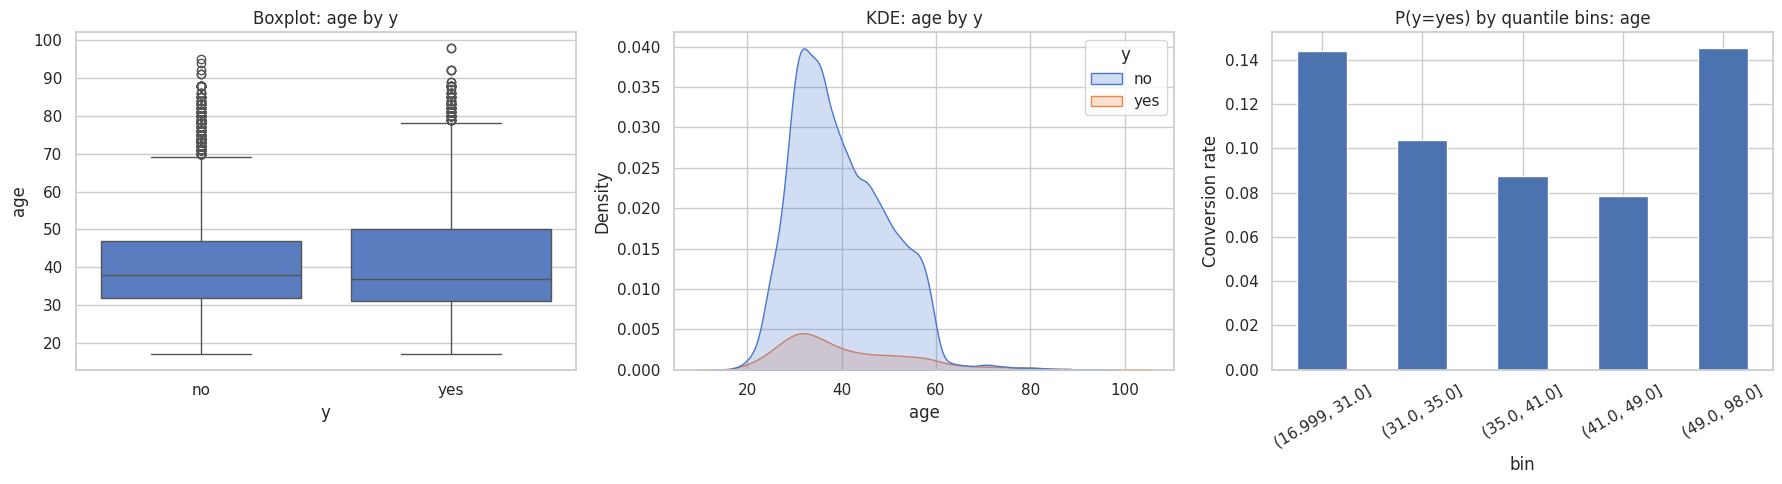

In [11]:
analyze_numeric_vs_target(df, 'age')

**Спостереження щодо числових ознак:**

- **duration**: Найсильніший роздільник між класами - довший дзвінок = зацікавлений клієнт. Але ця ознака відома лише після дзвінка тому **виключається** з фінальної моделі (data leakage).
- **euribor3m / emp.var.rate / nr.employed**: Клієнти `yes` концентруються при низьких значеннях - сильні макроекономічні предиктори.
- **pdays**: ~95% значень = 999 (не контактувався). Потребує спеціального кодування.
- **campaign**: Більше дзвінків = менше шансів (`yes`). Клієнти скоріш за все "втомлюються" від великої кількості дзвінків.
- **age**: U-подібна залежність: молоді (<30) та старші (>60) частіше погоджуються (тому варто зробити вікові групи).

### 1.4 Аналіз категоріальних ознак

Т.я. класи незбалансовані - аналізувати категоріальні ознаки вирішив не на загальній вибірці, а відносно частки підписаших контракти

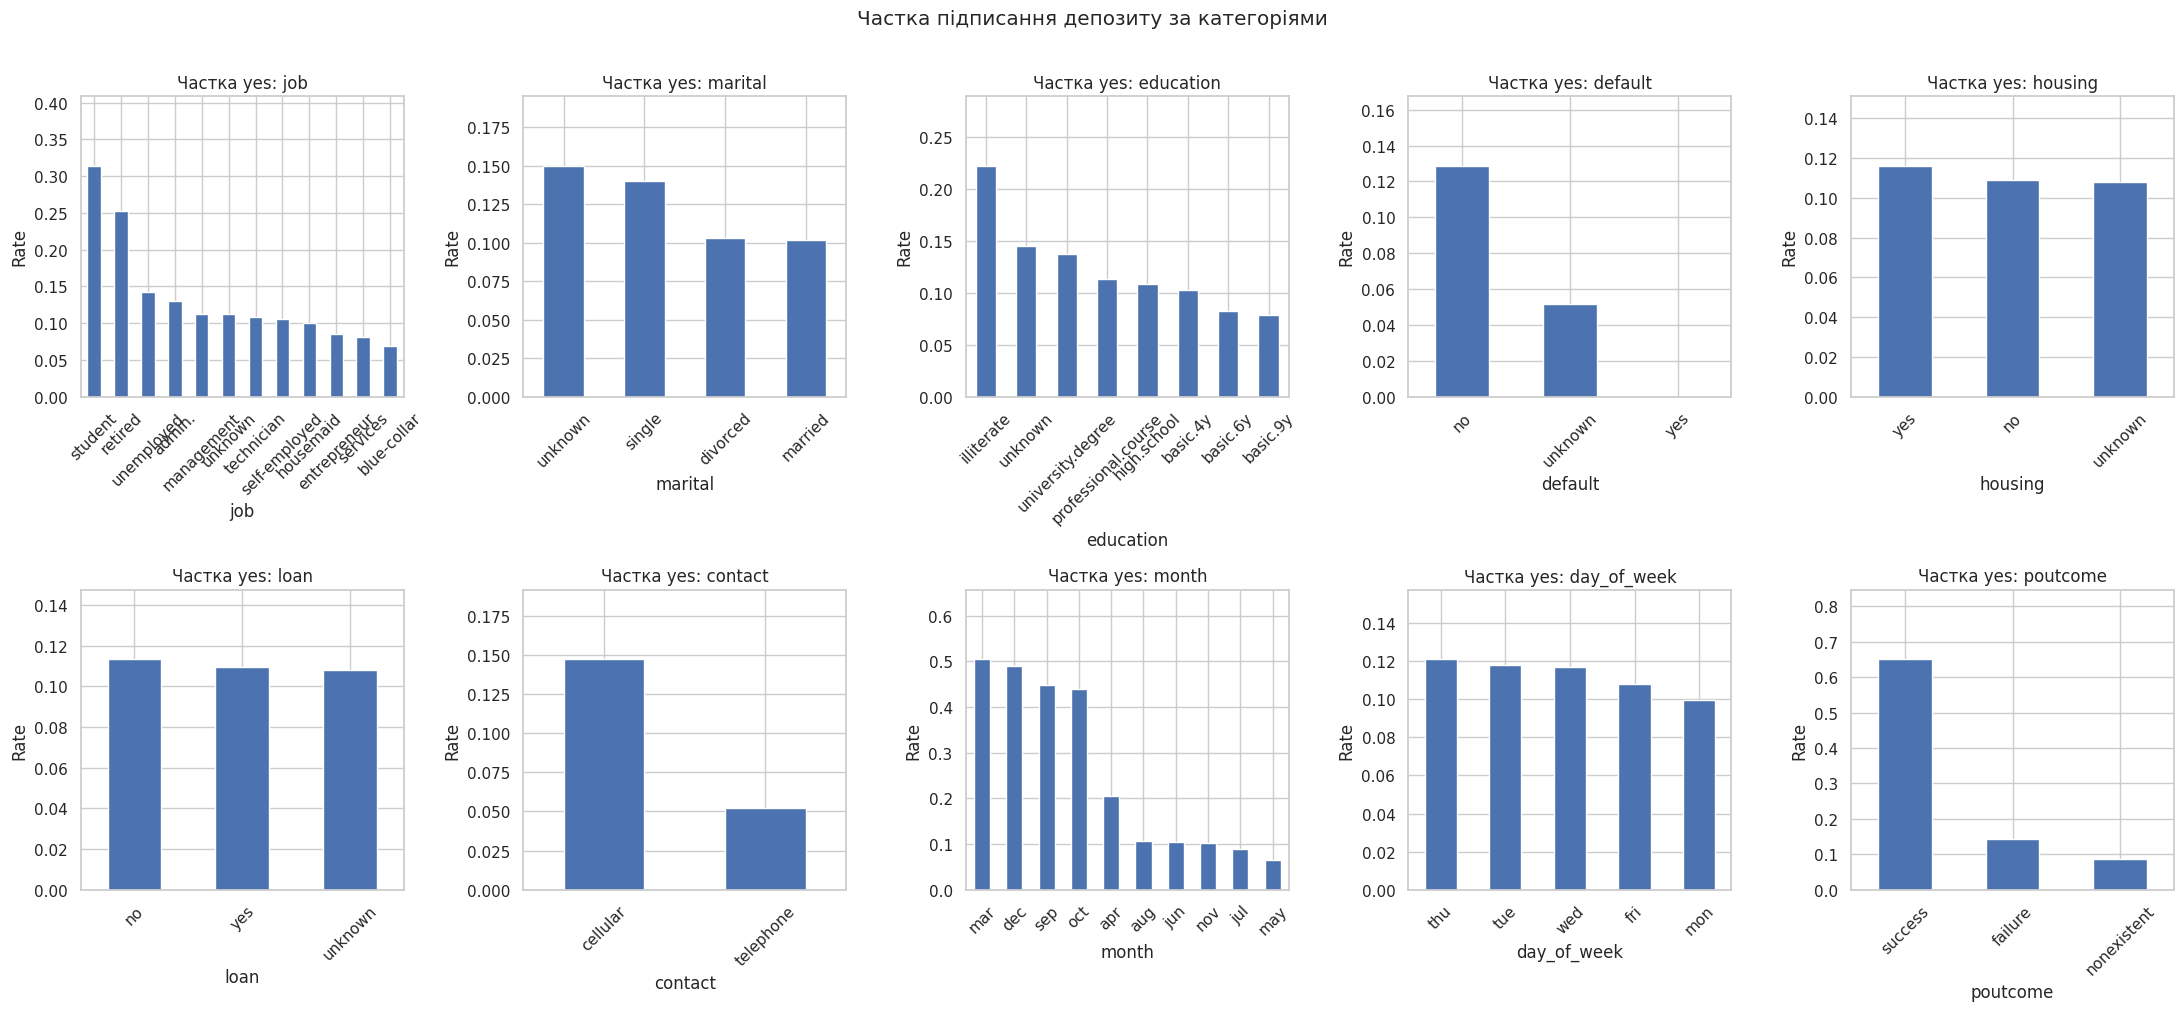

In [12]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Частка yes: {col}')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, rates.max() * 1.3)
plt.suptitle('Частка підписання депозиту за категоріями', y=1.01)
plt.tight_layout()
plt.show()

**Спостереження щодо категоріальних ознак:**

- **poutcome = success**: ~65% conversion — найсильніший предиктор серед категоріальних.
- **contact = cellular**: ~14.7% success vs стаціонарний ~5.2% — різниця в 3 рази.
- **month**: Березень, жовтень, грудень, вересень мають >25-40% conversion. Травень — найбільше дзвінків, але нижча ефективність. Варто згрупувати місяці.
- **job**: Студенти та пенсіонери — найвищий conversion. Синьокомірцеві — найнижчий.
- **marital**: Одинокі (14%) > одружені (10%). Можна об'єднати 'married/divorced/unknown' у 'not_single'.
- **day_of_week**: Майже однаковий conversion по всіх днях — слабкий предиктор, можна прибрати.
- **default, housing, loan**: Схожі частки для всіх значень — обмежена окрема інформативність.

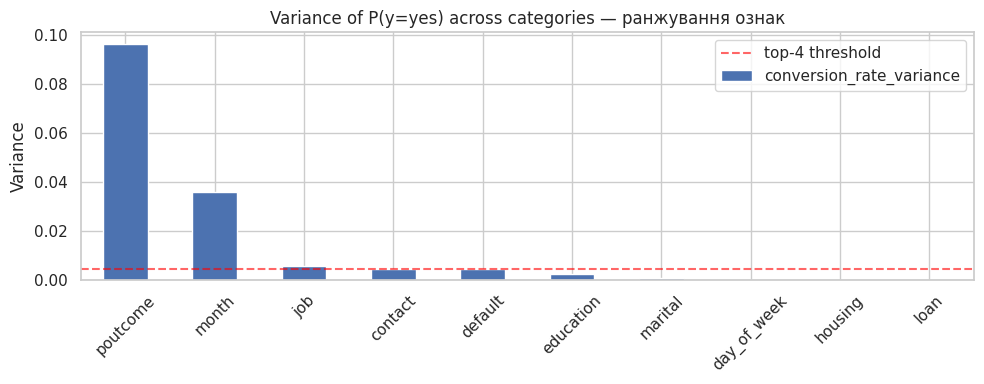

             conversion_rate_variance     std
poutcome                      0.09643  0.3105
month                         0.03593  0.1895
job                           0.00542  0.0736
contact                       0.00452  0.0672
default                       0.00420  0.0648
education                     0.00213  0.0462
marital                       0.00062  0.0250
day_of_week                   0.00008  0.0088
housing                       0.00002  0.0045
loan                          0.00001  0.0028


In [13]:
# Ранжуємо категоріальні ознаки за дисперсією conversion rate
# Чим вища дисперсія — тим більше ознака 'розділяє' класи
cat_cols_eda = ['job', 'marital', 'education', 'default',
                'housing', 'loan', 'contact', 'month',
                'day_of_week', 'poutcome']

conversion_variance = {}
for col in cat_cols_eda:
    rates = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean())
    conversion_variance[col] = rates.var()

rank_df = (
    pd.Series(conversion_variance, name='conversion_rate_variance')
    .sort_values(ascending=False)
    .to_frame()
)
rank_df['std'] = rank_df['conversion_rate_variance'].pow(0.5).round(4)

rank_df.plot(kind='bar', y='conversion_rate_variance',
             figsize=(10, 4), color='#4C72B0', edgecolor='white', legend=False)
plt.axhline(rank_df['conversion_rate_variance'].nlargest(4).iloc[-1],
            color='red', linestyle='--', alpha=0.6, label='top-4 threshold')
plt.title('Variance of P(y=yes) across categories — ранжування ознак')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(rank_df.round(5).to_string())

**Логіка відбору ознак для детального аналізу:**

Метрика — **дисперсія conversion rate** між категоріями: показує, наскільки сильно ознака розділяє клас `yes` від `no`. Обираємо **топ-4** з найвищою дисперсією:

| Ознака | Чому в топі |
|---|---|
| `poutcome` | Найбільша дисперсія: `success` ~65% vs `failure` ~8% |
| `contact` | Cellular ~15% vs telephone ~5% — різниця в 3 рази |
| `month` | Чітка сезонність: mar/dec/oct >30%, jun/jul/aug <8% |
| `job` | Студенти/пенсіонери >25%, синьокомірцеві ~7% |

**Не беремо:**
- `default`, `housing`, `loan` — низька дисперсія, майже однакова конверсія по всіх значеннях
- `day_of_week` — мінімальна різниця між днями
- `marital`, `education` — помірна різниця, достатньо загального графіку

#### Детальний аналіз чотирьох обраних категоріальних ознак

______Підрахунок значень колонки 'poutcome'______

Топ 3 значень:

Значення        |  Кількість | Відсоток
------------------------------------------
nonexistent     |      35551 |   86.34%
failure         |       4252 |   10.33%
success         |       1373 |    3.33%

------------------------------------------
  Аналіз: poutcome
------------------------------------------
Unique categories: 3

P(y=yes) by poutcome:
success        65.1%
failure        14.2%
nonexistent     8.8%


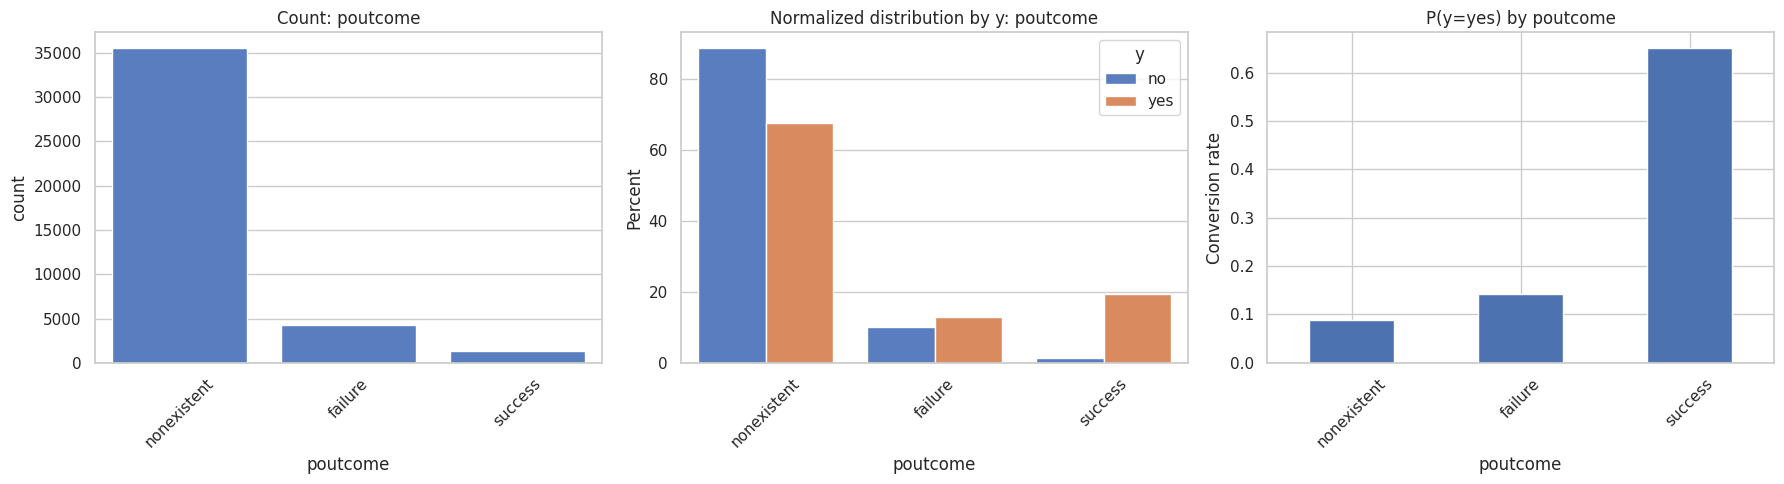

In [14]:
value_counts_of_column(df, 'poutcome', n=3)
analyze_categorical_vs_target(df, 'poutcome')

______Підрахунок значень колонки 'contact'______

Топ 2 значень:

Значення        |  Кількість | Відсоток
------------------------------------------
cellular        |      26135 |   63.47%
telephone       |      15041 |   36.53%

------------------------------------------
  Аналіз: contact
------------------------------------------
Unique categories: 2

P(y=yes) by contact:
cellular     14.7%
telephone     5.2%


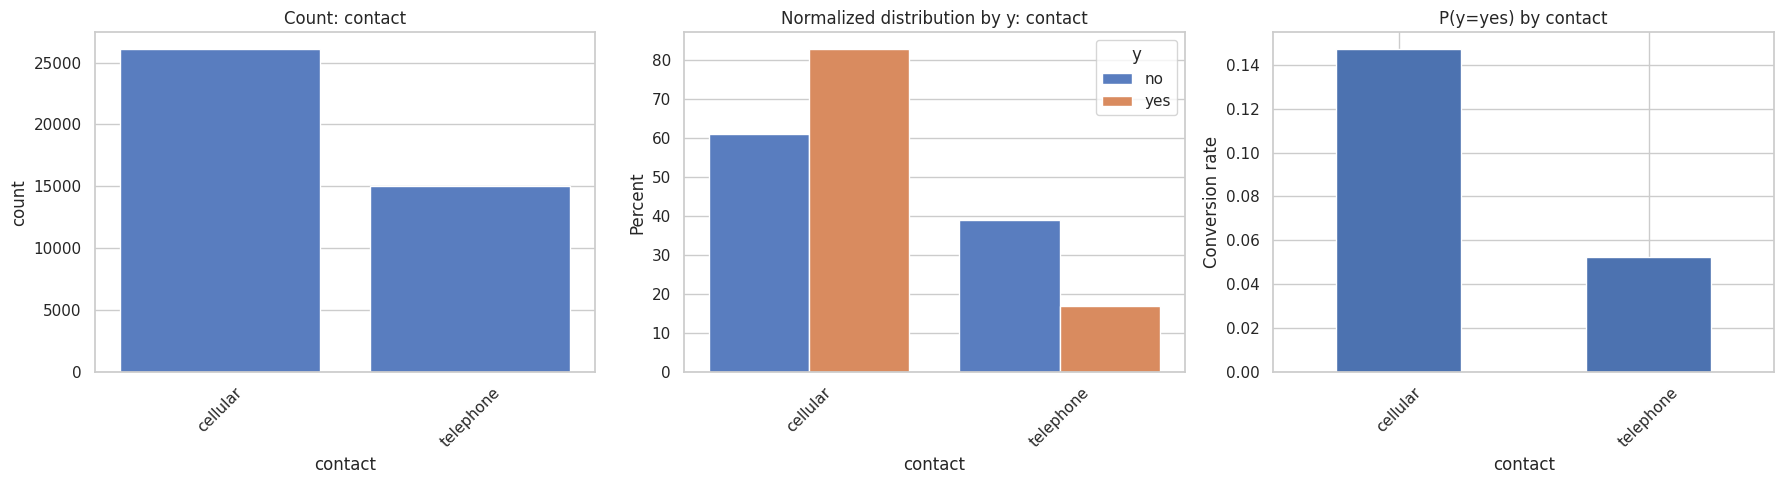

In [15]:
value_counts_of_column(df, 'contact', n=2)
analyze_categorical_vs_target(df, 'contact')

______Підрахунок значень колонки 'month'______

Топ 10 значень:

Значення        |  Кількість | Відсоток
------------------------------------------
may             |      13767 |   33.43%
jul             |       7169 |   17.41%
aug             |       6176 |   15.00%
jun             |       5318 |   12.92%
nov             |       4100 |    9.96%
apr             |       2631 |    6.39%
oct             |        717 |    1.74%
sep             |        570 |    1.38%
mar             |        546 |    1.33%
dec             |        182 |    0.44%

------------------------------------------
  Аналіз: month
------------------------------------------
Unique categories: 10

P(y=yes) by month:
mar    50.5%
dec    48.9%
sep    44.9%
oct    43.9%
apr    20.5%
aug    10.6%
jun    10.5%
nov    10.1%
jul     9.0%
may     6.4%


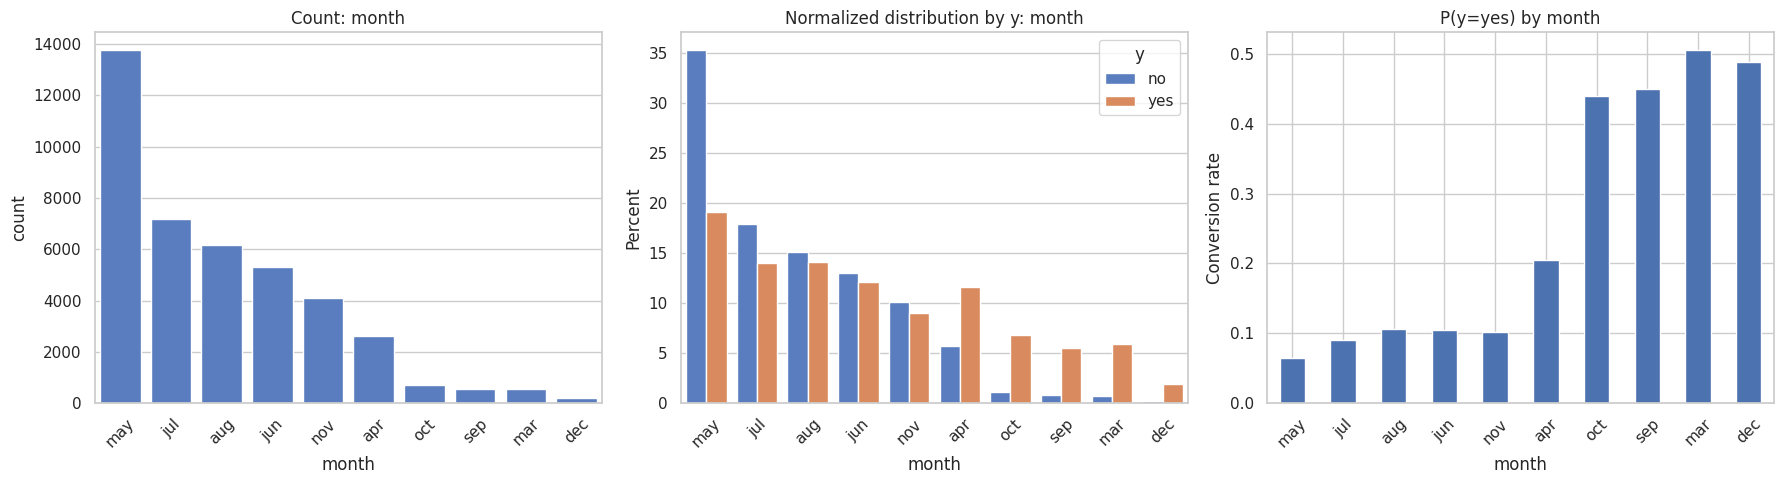

In [16]:
value_counts_of_column(df, 'month', n=10)
analyze_categorical_vs_target(df, 'month')

______Підрахунок значень колонки 'job'______

Топ 12 значень:

Значення        |  Кількість | Відсоток
------------------------------------------
admin.          |      10419 |   25.30%
blue-collar     |       9253 |   22.47%
technician      |       6739 |   16.37%
services        |       3967 |    9.63%
management      |       2924 |    7.10%
retired         |       1718 |    4.17%
entrepreneur    |       1456 |    3.54%
self-employed   |       1421 |    3.45%
housemaid       |       1060 |    2.57%
unemployed      |       1014 |    2.46%
student         |        875 |    2.13%
unknown         |        330 |    0.80%

------------------------------------------
  Аналіз: job
------------------------------------------
Unique categories: 12

P(y=yes) by job:
student          31.4%
retired          25.3%
unemployed       14.2%
admin.           13.0%
management       11.2%
unknown          11.2%
technician       10.8%
self-employed    10.5%
housemaid        10.0%
entrepreneur      8.5%
ser

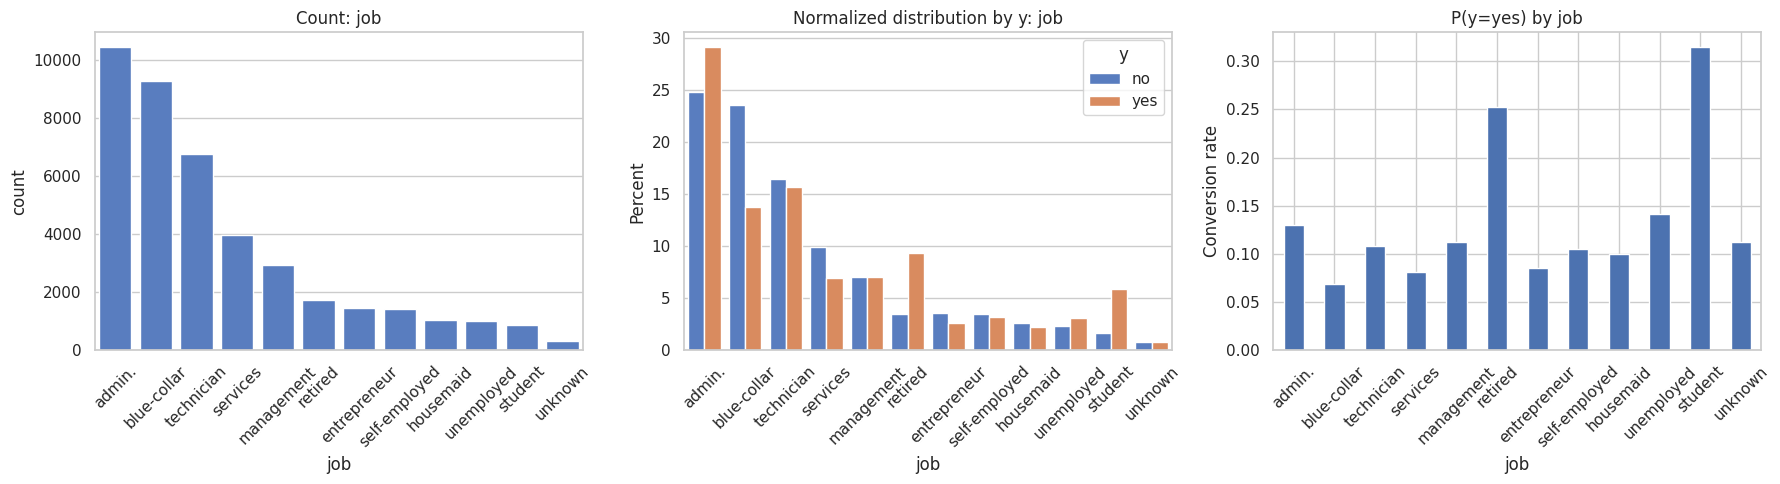

In [17]:
value_counts_of_column(df, 'job', n=12)
analyze_categorical_vs_target(df, 'job')

### 1.6 Гіпотези щодо впливу ознак на ціль

1. **duration** - найсильніший предиктор, але виключається (data leakage).
2. **poutcome = success** - попередня успішна кампанія дає ~6.5x вищу ймовірність.
3. **contact = cellular** - ефективніший у 3 рази за стаціонарний.
4. **month** - березень/вересень/жовтень/грудень суттєво ефективніші - можливо є сенс групувати по сезонам.
5. **job = student/retired** - ці групи частіше підписують депозит.
6. **age** - U-подібна залежність тому робимо вікові категорії.
7. **Макроекономічні індикатори** - низькі euribor3m та emp.var.rate корелюють з більшим `yes`.
8. **pdays < 999** + **previous > 0** → суттєво вища ймовірність `yes`.

---
## 2. Вибір методів та метрики оцінки

**Метрика: ROC-AUC (основна) + F1-score (додаткова)**

Обґрунтування:
- Датасет **сильно незбалансований** (88.7% / 11.3%) тому Accuracy марна.
- **ROC-AUC** вимірює здатність ранжувати клієнтів — саме це потрібно маркетологам (дзвонити топ-N зі списку пріоритетів).
- **F1-score** враховує баланс Precision/Recall для класу `yes` — корисна для бізнес-інтерпретації.
- PR-AUC була б ще точнішою для меншинного класу, але ROC-AUC — стандарт для порівняння.

**Моделі:**
- Logistic Regression — інтерпретована базова лінійна модель
- kNN — нелінійна модель, заснована на відстані
- Decision Tree — інтерпретована нелінійна модель
- XGBoost — потужний бустинг-алгоритм
- LightGBM — ефективна альтернатива XGBoost, часто швидша

---
## 3. Препроцесинг даних

Включає: обробку outliers, видалення нерелевантних ознак, feature engineering, кодування категоріальних змінних, поділ на train/val та масштабування.

### 3.1 Аналіз outliers

Аналізуємо **тільки клієнтські числові ознаки** — там outliers можуть бути справжніми аномаліями у даних конкретного клієнта.

Макроекономічні індикатори (`euribor3m`, `emp.var.rate`, `nr.employed`, `cons.price.idx`, `cons.conf.idx`) **не аналізуємо** — це системні показники: всі клієнти за один місяць мають однакове значення, тому 'outlier' там означає аномальний економічний період, а не помилку в даних.

`pdays` **аналізуємо окремо** — значення 999 є навмисним кодуванням ('не контактувався'); спочатку виключаємо його і дивимось на реальний розподіл днів для клієнтів, що були контактовані раніше.

          min   max    IQR  lower_bound  upper_bound  n_outliers  pct_outliers
column                                                                        
age        17    98   15.0          9.5         69.5         468          1.14
duration    0  4918  217.0       -223.5        644.5        2963          7.20
campaign    1    56    2.0         -2.0          6.0        2406          5.84
previous    0     7    0.0          0.0          0.0        5625         13.66


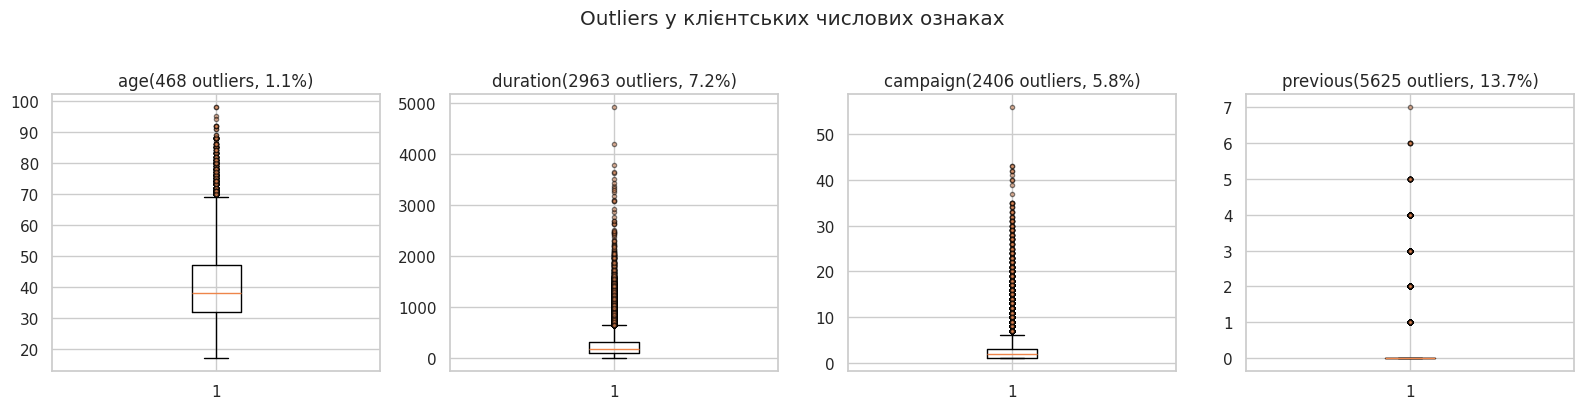

campaign — percentile breakdown:
count    41176.0
mean         2.6
std          2.8
min          1.0
50%          2.0
75%          3.0
95%          7.0
99%         14.0
99.9%       29.0
max         56.0
Name: campaign, dtype: float64


In [18]:
client_num_cols = ['age', 'duration', 'campaign', 'previous']

# Зведена IQR-таблиця для всіх чотирьох колонок
iqr_rows = []

for col in client_num_cols:
    b = calculate_iqr_bounds(df, col)
    iqr_rows.append({
        'column':      col,
        'min':         df[col].min(),
        'max':         df[col].max(),
        'IQR':         round(b['IQR'], 2),
        'lower_bound': round(b['lower'], 2),
        'upper_bound': round(b['upper'], 2),
        'n_outliers':  b['n_outliers'],
        'pct_outliers':round(b['pct_outliers'], 2),
    })

iqr_df = pd.DataFrame(iqr_rows).set_index('column')
print(iqr_df.to_string())

# Boxplot для візуалізації
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, client_num_cols):
    ax.boxplot(df[col], flierprops=dict(marker='o', markersize=3,
                                        markerfacecolor='#DD8452', alpha=0.5))
    b = calculate_iqr_bounds(df, col)
    ax.set_title(f"{col}({b['n_outliers']} outliers, {b['pct_outliers']:.1f}%)")
plt.suptitle('Outliers у клієнтських числових ознаках', y=1.02)
plt.tight_layout()
plt.show()

# Детальний percentile breakdown для campaign
print('campaign — percentile breakdown:')
print(df['campaign'].describe(percentiles=[0.75, 0.95, 0.99, 0.999]).round(1))

**Висновки та рішення по кожній колонці:**

| Колонка | Ситуація | Рішення |
|---|---|---|
| `campaign` | ~1–2% outliers, max=56, але 99-й перцентиль ≈14. Екстремальні значення - реальні аномалії (клієнт, якому дзвонили 50+ разів) | **Cap на 99-му перцентилі** робимо в `engineer_features` |
| `age` | Кілька клієнтів >80 років | **Нічого не робимо** - трансформуємо в `age_group`, категорія `senior` їх охопить |
| `previous` | 99%+ значень 0–2, поодинокі до 7 | **Нічого** - перетворюємо на `contacted_before`, категорія `2+times` їх об'єднає |
| `duration` | Є outliers (дзвінки >3000 сек), але колонка **видаляється** | **Видаляємо** - data leakage: значення відоме лише після дзвінка |

In [19]:
# pdays: аналізуємо тільки реальні значення (виключаємо 999)
pdays_real = df[df['pdays'] != 999]['pdays']
n_999 = (df['pdays'] == 999).sum()
n_real = len(pdays_real)
n_total = len(df)

print(f'Клієнтів з реальним pdays: {n_real} ({n_real/n_total*100:.1f}% від датасету)')
print(f'Клієнтів з pdays=999:      {n_999} ({n_999/n_total*100:.1f}%)')

Клієнтів з реальним pdays: 1515 (3.7% від датасету)
Клієнтів з pdays=999:      39661 (96.3%)


In [20]:
# IQR-аналіз реальних значень
b = calculate_iqr_bounds(df[df['pdays'] != 999], 'pdays')
print(f'\nРозподіл реальних pdays:')
print(pdays_real.describe().round(1).to_string())
print(f'IQR: {b["IQR"]:.1f}')
print(f'Outlier bounds: [{b["lower"]:.1f}, {b["upper"]:.1f}]')
print(f'Outliers у підмножині: {b["n_outliers"]} ({b["pct_outliers"]:.1f}%)')


Розподіл реальних pdays:
count    1515.0
mean        6.0
std         3.8
min         0.0
25%         3.0
50%         6.0
75%         7.0
max        27.0
IQR: 4.0
Outlier bounds: [-3.0, 13.0]
Outliers у підмножині: 82 (5.4%)


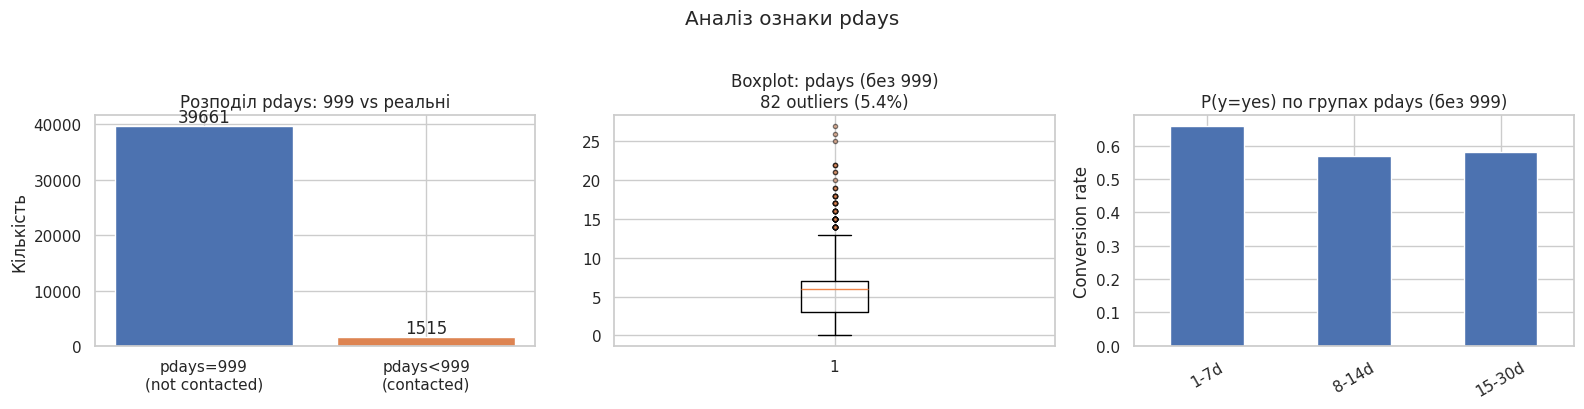

In [21]:
# Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Вся колонка vs відфільтрована
bar_vals = [n_999, n_real]
bar_labels = ['pdays=999\n(not contacted)', 'pdays<999\n(contacted)']
bars = axes[0].bar(bar_labels, bar_vals, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Розподіл pdays: 999 vs реальні')
axes[0].set_ylabel('Кількість')
for bar, v in zip(bars, bar_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 100,
                 str(v), ha='center', va='bottom')

# 2. Boxplot реальних значень
axes[1].boxplot(pdays_real,
                flierprops=dict(marker='o', markersize=3,
                                markerfacecolor='#DD8452', alpha=0.5))
axes[1].set_title(f'Boxplot: pdays (без 999)\n'
                  f'{b["n_outliers"]} outliers ({b["pct_outliers"]:.1f}%)')

# 3. Conversion rate по групах pdays
df_contacted = df[df['pdays'] != 999].copy()
df_contacted['pdays_bin'] = pd.cut(df_contacted['pdays'],
                                   bins=[0, 7, 14, 30, 100, 1000],
                                   labels=['1-7d', '8-14d', '15-30d', '31-100d', '>100d'])
conv = df_contacted.groupby('pdays_bin', observed=True)['y'].apply(lambda x: (x == 'yes').mean())
conv.plot(kind='bar', ax=axes[2], color='#4C72B0', edgecolor='white')
axes[2].set_title('P(y=yes) по групах pdays (без 999)')
axes[2].set_ylabel('Conversion rate')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Аналіз ознаки pdays', y=1.02)
plt.tight_layout()
plt.show()

**Висновки з аналізу pdays:**

- **~96%** клієнтів мають `pdays=999` — ніколи не контактувались у попередніх кампаніях.
- Серед решти ~4% є outliers за IQR-критерієм, але вони не потребують cap — колонка **не використовується напряму** у фінальній моделі.
- Графік конверсії по бінах показує: чим **менше днів** пройшло з останнього контакту, тим вища ймовірність `yes`. Клієнти, контактовані 1–7 днів тому, конвертуються значно краще за тих, з ким не спілкувались >100 днів.

**Рішення:** замість числового `pdays` і `previous` створюємо категорію `contacted_before` з 4 рівнями — вона краще передає бізнес-логіку і не несе проблем з outliers.

### 3.2 Feature Engineering та кодування

Всі трансформації винесено у `process_bank_marketing.py` → функція `engineer_features()`:

- видалення `duration` (data leakage) та `day_of_week` (не інформативний)
- `age_group` — вікові категорії замість числового віку
- `contacted_before` — 4 рівні з `pdays` + `previous`
- `period` — групи місяців за conversion rate
- ordinal encoding для `education`
- cap outliers у `campaign` на 99-му перцентилі
- OHE для всіх номінальних категоріальних ознак

In [22]:
#препроцесинг
df_proc = engineer_features(df)
print('Shape після feature engineering:', df_proc.shape)
print('Нові/змінені колонки:', [c for c in df_proc.columns if any (p in c for p in ['age_group','contacted','period','education_ord'])])

Shape після feature engineering: (41176, 41)
Нові/змінені колонки: ['education_ord', 'age_group_30-40', 'age_group_40-50', 'age_group_50-60', 'age_group_senior', 'age_group_young', 'contacted_before_2+times', 'contacted_before_contacted_long_ago', 'contacted_before_not_contacted', 'period_low_season', 'period_mid_season']


### 3.3 Train/Val split та масштабування

`prepare_train_val()` з `process_bank_marketing.py` виконує:
1. Стратифікований поділ (зберігає пропорцію класів)
2. `StandardScaler` — fit тільки на train, щоб уникнути data leakage
3. Повертає і scaled (для LogReg/kNN), і unscaled (для tree-based) версії

In [23]:
data = prepare_train_val(df_proc, test_size=0.2, random_state=RANDOM_STATE)

X_train = data['X_train']
X_val = data['X_val']
X_train_sc = data['X_train_sc']
X_val_sc = data['X_val_sc']
y_train = data['y_train']
y_val = data['y_val']
feature_cols = data['feature_cols']
scaler = data['scaler']

print(f'Train: {X_train.shape},  Val: {X_val.shape}')
print(f'Positive rate — train: {y_train.mean():.3f},  val: {y_val.mean():.3f}')
print(f'Features: {len(feature_cols)}')

Train: (32940, 40),  Val: (8236, 40)
Positive rate — train: 0.113,  val: 0.113
Features: 40


---
## 4. Тренування моделей

Тренуємо 5 типів моделей. Для кожної фіксуємо ROC-AUC, F1, Recall та Precision — щоб мати повну картину якості з урахуванням дисбалансу класів.

In [41]:
results = []
trained_models_proba = {}

def evaluate(name, model, X_tr, X_v, y_tr, y_v, params='default',
             X_tr_raw=None, X_v_raw=None):
    """Обчислює ключові метрики та записує в таблицю результатів."""

    Xtr = X_tr_raw if X_tr_raw is not None else X_tr
    Xv  = X_v_raw  if X_v_raw  is not None else X_v

    train_proba = model.predict_proba(Xtr)[:, 1]
    val_proba   = model.predict_proba(Xv)[:, 1]

    train_auc = roc_auc_score(y_tr, train_proba)
    val_auc   = roc_auc_score(y_v,  val_proba)

    val_pred  = (val_proba >= 0.5).astype(int)
    val_f1    = f1_score(y_v,   val_pred)
    val_rec   = recall_score(y_v,  val_pred)
    val_prec  = precision_score(y_v, val_pred)

    diff = train_auc - val_auc
    if diff > 0.05:      comment = 'High variance (overfit)'
    elif val_auc < 0.75: comment = 'High bias (underfit)'
    else:                comment = 'Good'

    # уникаємо дублікатів при повторному запуску комірки моделі
    results[:] = [r for r in results if r['Model'] != name]
    results.append({
        'Model': name, 'Params': str(params),
        'Train AUC': round(train_auc, 4), 'Val AUC': round(val_auc, 4),
        'Val F1': round(val_f1, 4), 'Val Recall': round(val_rec, 4),
        'Val Precision': round(val_prec, 4), 'Comment': comment
    })
    trained_models_proba[name] = val_proba
    print(f'{name:45s}  Train AUC={train_auc:.4f}  Val AUC={val_auc:.4f}'
          f'  F1={val_f1:.4f}  [{comment}]')
    return val_auc

### 4.1 Baseline: DummyClassifier

Модель, яка завжди передбачає більшинний клас (`no`) — наш мінімальний поріг якості.

In [43]:
# Baseline: завжди каже 'no' — нижня межа для порівняння
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

dummy.fit(X_train_sc, y_train)

evaluate('Dummy (most_frequent)', dummy, X_train_sc, X_val_sc, y_train, y_val,
         params='strategy=most_frequent')

Dummy (most_frequent)                          Train AUC=0.5000  Val AUC=0.5000  F1=0.0000  [High bias (underfit)]


np.float64(0.5)

### 4.2 Logistic Regression

Лінійна базова модель — швидка, добре інтерпретується через коефіцієнти. `class_weight='balanced'` автоматично компенсує дисбаланс.

In [44]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    C=0.1
)

lr.fit(X_train_sc, y_train)

evaluate('Logistic Regression (C=0.1, balanced)', lr,
         X_train_sc, X_val_sc, y_train, y_val,
         params='C=0.1, class_weight=balanced')

print('\nClassification Report (val):')
print(classification_report(y_val, (lr.predict_proba(X_val_sc)[:,1]>=0.5).astype(int),
                             target_names=['no','yes']))

Logistic Regression (C=0.1, balanced)          Train AUC=0.7889  Val AUC=0.7946  F1=0.4466  [Good]

Classification Report (val):
              precision    recall  f1-score   support

          no       0.95      0.83      0.89      7308
         yes       0.33      0.68      0.45       928

    accuracy                           0.81      8236
   macro avg       0.64      0.75      0.67      8236
weighted avg       0.88      0.81      0.84      8236



### 4.3 kNN

Модель, заснована на схожості клієнтів. Чутлива до масштабу ознак, тому обов'язково потребує scaled даних.

In [45]:
knn = KNeighborsClassifier(
    n_neighbors=25,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_train_sc, y_train)

evaluate('kNN (k=25, distance weights)', knn,
         X_train_sc, X_val_sc, y_train, y_val,
         params='k=25, weights=distance')

kNN (k=25, distance weights)                   Train AUC=0.9990  Val AUC=0.7323  F1=0.3209  [High variance (overfit)]


np.float64(0.732308520539607)

### 4.4 Decision Tree

Інтерпретована нелінійна модель. Обмежуємо глибину, щоб уникнути overfit.

In [46]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

dt.fit(X_train, y_train)

evaluate('Decision Tree (depth=8, balanced)', dt,
         X_train_sc, X_val_sc, y_train, y_val,
         params='max_depth=8, min_samples_leaf=20',
         X_tr_raw=X_train, X_v_raw=X_val)

Decision Tree (depth=8, balanced)              Train AUC=0.8060  Val AUC=0.7982  F1=0.4700  [Good]


np.float64(0.7981825390927278)

### 4.5 XGBoost (базова версія)

Градієнтний бустинг — як правило найкращий алгоритм на табличних даних. `scale_pos_weight` компенсує дисбаланс класів.

In [47]:
# scale_pos_weight = neg/pos → автоматично посилює увагу до меншинного класу
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    tree_method='hist',
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbosity=0,
)

xgb_base.fit(X_train, y_train)

evaluate('XGBoost base (depth=4, n=300)', xgb_base,
         X_train_sc, X_val_sc, y_train, y_val,
         params='n=300, depth=4, lr=0.1',
         X_tr_raw=X_train, X_v_raw=X_val)

scale_pos_weight = 7.88
XGBoost base (depth=4, n=300)                  Train AUC=0.8619  Val AUC=0.8058  F1=0.4667  [High variance (overfit)]


np.float64(0.8057570500207614)

### 4.6 LightGBM (базова версія)

Ефективна реалізація градієнтного бустингу. Зазвичай швидша за XGBoost та дає порівнянну або кращу точність.

In [48]:
lgb_base = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

lgb_base.fit(X_train, y_train)

evaluate('LightGBM base (depth=4, n=300)', lgb_base,
         X_train_sc, X_val_sc, y_train, y_val,
         params='n=300, depth=4, lr=0.1',
         X_tr_raw=X_train, X_v_raw=X_val)

LightGBM base (depth=4, n=300)                 Train AUC=0.8551  Val AUC=0.8106  F1=0.4757  [Good]


np.float64(0.8105500083753279)

---
## 5. Порівняння моделей

Зводимо результати всіх базових моделей у єдину таблицю та будуємо ROC-криві для наочного порівняння.

In [49]:
# Таблиця результатів базових моделей, відсортована за Val AUC
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Val AUC', ascending=False).reset_index(drop=True)

display(
    df_results.style
    .background_gradient(subset=['Train AUC', 'Val AUC', 'Val F1'], cmap='YlGn')
    .set_caption('Порівняння базових моделей за метриками на валідаційній вибірці')
)

,Model,Params,Train AUC,Val AUC,Val F1,Val Recall,Val Precision,Comment
0,"LightGBM base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.855100,0.810600,0.475700,0.648700,0.375500,Good
1,"XGBoost base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.861900,0.805800,0.466700,0.649800,0.364100,High variance (overfit)
2,"Decision Tree (depth=8, balanced)","max_depth=8, min_samples_leaf=20",0.806000,0.798200,0.470000,0.629300,0.375100,Good
3,"Logistic Regression (C=0.1, balanced)","C=0.1, class_weight=balanced",0.788900,0.794600,0.446600,0.681000,0.332300,Good
4,"kNN (k=25, distance weights)","k=25, weights=distance",0.999000,0.732300,0.320900,0.254300,0.434600,High variance (overfit)
5,Dummy (most_frequent),strategy=most_frequent,0.500000,0.500000,0.000000,0.000000,0.000000,High bias (underfit)


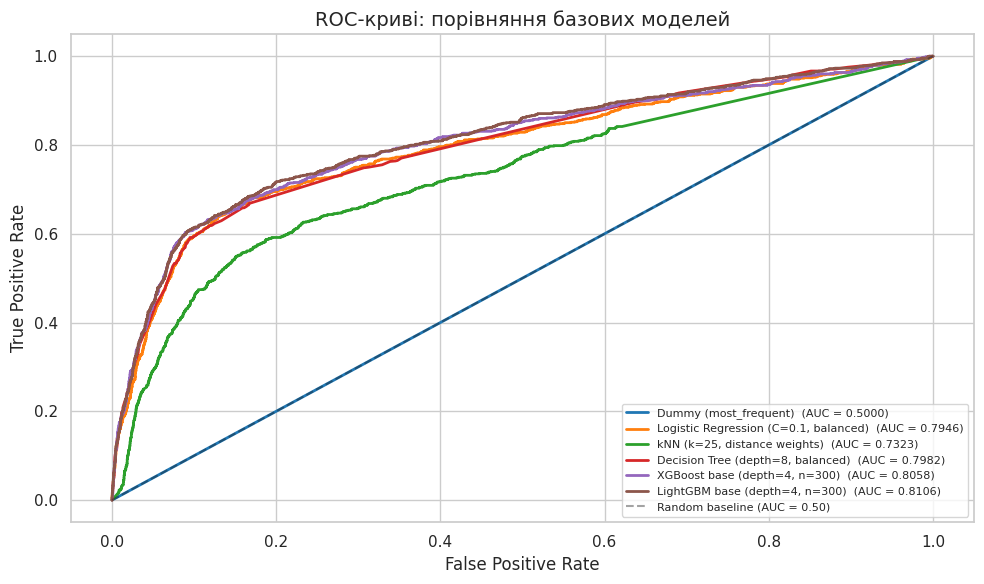

In [50]:
# ROC-криві для всіх базових моделей
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, (name, proba) in enumerate(trained_models_proba.items()):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, color=colors[i % 10], lw=2,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-криві: порівняння базових моделей', fontsize=14)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Висновки по базових моделях:**

| Модель | Val AUC | Коментар |
|--------|---------|----------|
| LightGBM base | **0.8106** | Найкращий базовий результат |
| XGBoost base  | 0.8058 | Близький до LightGBM, але трохи гірше |
| Decision Tree | 0.7982 | Конкурентний для простої моделі; добре інтерпретується |
| Logistic Regression | 0.7946 | Сильний результат для лінійної моделі |
| kNN | 0.7323 | Overfit (Train − Val > 0.05) |
| Dummy | 0.5000 | Нижня межа — випадкове вгадування |

**Ключові спостереження:**
- Обидва бустинг-алгоритми лідирують - вони краще захоплюють нелінійні залежності між ознаками.
- Logistic Regression дає AUC 0.79 попри лінійну природу - сигнал у наших ознаках достатньо сильний і добре виражений після OHE.
- kNN страждає від overfitting при великій кількості sparse бінарних ознак після one-hot encoding.
- Decision Tree з обмеженою глибиною показує хорошу якість — підтверджує, що feature engineering (age_group, contacted_before, period) додав чіткий сигнал.

**Наступний крок:** підбір гіперпараметрів LightGBM — він показав найкращий базовий Val AUC.

---
## 6. Підбір гіперпараметрів LightGBM

Застосовуємо два методи: **RandomizedSearchCV** (sklearn) та **Bayesian Optimization** (Hyperopt TPE).  
LightGBM обрано як базово найкращу модель (Val AUC = 0.8106).

### 6.1 RandomizedSearchCV

Випадковий пошук по заданому розподілу гіперпараметрів. Швидше за GridSearch, але кожна комбінація вибирається **незалежно** — без врахування результатів попередніх спроб.

In [51]:
from scipy.stats import randint, uniform as sp_uniform

param_dist = {
    'n_estimators': randint(100, 700),
    'max_depth': randint(3, 9),
    'learning_rate': sp_uniform(0.01, 0.29),
    'num_leaves': randint(20, 100),
    'subsample': sp_uniform(0.6, 0.4),
    'colsample_bytree': sp_uniform(0.6, 0.4),
    'min_child_samples': randint(10, 60),
    'reg_alpha': sp_uniform(0, 1),
    'reg_lambda': sp_uniform(0, 1),
}

lgb_for_rs = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rs = RandomizedSearchCV(
    estimator=lgb_for_rs,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rs.fit(X_train, y_train)

print(f'\nBest CV AUC: {rs.best_score_:.4f}')
print('Best params:')
for k, v in rs.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV AUC: 0.8036
Best params:
  colsample_bytree: 0.6976502088991097
  learning_rate: 0.05880440223014986
  max_depth: 3
  min_child_samples: 58
  n_estimators: 596
  num_leaves: 77
  reg_alpha: 0.9624472949421112
  reg_lambda: 0.25178229582536416
  subsample: 0.7988994023569542


In [52]:
lgb_rs_best = rs.best_estimator_
evaluate(
    'LightGBM (RandomizedSearchCV)', lgb_rs_best,
    X_train_sc, X_val_sc, y_train, y_val,
    params=rs.best_params_,
    X_tr_raw=X_train, X_v_raw=X_val,
)

LightGBM (RandomizedSearchCV)                  Train AUC=0.8341  Val AUC=0.8116  F1=0.4801  [Good]


np.float64(0.8116458050223657)

### 6.2 Hyperopt — Bayesian Optimization (TPE)

TPE (Tree-structured Parzen Estimator) будує probabilistic model по вже перевірених точках і **спрямовує пошук** у перспективні зони простору параметрів. При однаковій кількості ітерацій знаходить кращий або рівноцінний результат порівняно з RandomizedSearchCV.

In [53]:
from sklearn.model_selection import cross_val_score

def objective(params):
    # hp.quniform повертає float — конвертуємо в int для дискретних параметрів
    int_keys = ['n_estimators', 'max_depth', 'num_leaves', 'min_child_samples']
    for k in int_keys:
        params[k] = int(params[k])

    model = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        verbosity=-1,
        **params,
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}


space = {
    'n_estimators':      hp.quniform('n_estimators', 100, 700, 50),
    'max_depth':         hp.quniform('max_depth', 3, 8, 1),
    'learning_rate':     hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'num_leaves':        hp.quniform('num_leaves', 20, 100, 5),
    'subsample':         hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree':  hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_samples': hp.quniform('min_child_samples', 10, 60, 5),
    'reg_alpha':         hp.uniform('reg_alpha', 0, 1),
    'reg_lambda':        hp.uniform('reg_lambda', 0, 1),
}

trials = Trials()
best_params_ho = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE),
)

print('\nBest params (Hyperopt):')
for k, v in best_params_ho.items():
    print(f'  {k}: {v}')
print(f'Best CV AUC: {-min(trials.losses()):.4f}')

100%|██████████| 50/50 [06:31<00:00,  7.82s/trial, best loss: -0.8032249749539071]

Best params (Hyperopt):
  colsample_bytree: 0.7367490548689456
  learning_rate: 0.010188411809459156
  max_depth: 7.0
  min_child_samples: 15.0
  n_estimators: 450.0
  num_leaves: 25.0
  reg_alpha: 0.8609304819134347
  reg_lambda: 0.6082491621711366
  subsample: 0.7201685419162034
Best CV AUC: 0.8032


In [54]:
int_keys = ['n_estimators', 'max_depth', 'num_leaves', 'min_child_samples']
ho_params_clean = {
    k: int(v) if k in int_keys else v
    for k, v in best_params_ho.items()
}

lgb_ho_best = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    verbosity=-1,
    **ho_params_clean,
)
lgb_ho_best.fit(X_train, y_train)

evaluate(
    'LightGBM (Hyperopt)', lgb_ho_best,
    X_train_sc, X_val_sc, y_train, y_val,
    params=ho_params_clean,
    X_tr_raw=X_train, X_v_raw=X_val,
)

LightGBM (Hyperopt)                            Train AUC=0.8322  Val AUC=0.8149  F1=0.4871  [Good]


np.float64(0.8148540127257801)

In [55]:
# Порівнюємо два методи тюнінгу та обираємо найкращу модель
rs_auc   = roc_auc_score(y_val, lgb_rs_best.predict_proba(X_val)[:, 1])
ho_auc   = roc_auc_score(y_val, lgb_ho_best.predict_proba(X_val)[:, 1])
base_auc = roc_auc_score(y_val, lgb_base.predict_proba(X_val)[:, 1])

print(f'LightGBM base              Val AUC: {base_auc:.4f}  (базова лінія)')
print(f'LightGBM RandomizedSearch  Val AUC: {rs_auc:.4f}  (delta: {rs_auc - base_auc:+.4f})')
print(f'LightGBM Hyperopt          Val AUC: {ho_auc:.4f}  (delta: {ho_auc - base_auc:+.4f})')

if ho_auc >= rs_auc:
    lgb_best = lgb_ho_best
    best_tuned_name = 'LightGBM (Hyperopt)'
else:
    lgb_best = lgb_rs_best
    best_tuned_name = 'LightGBM (RandomizedSearchCV)'

print(f'\nОбрана модель для подальшого аналізу: {best_tuned_name}')
print(f'Val AUC: {max(ho_auc, rs_auc):.4f}')

LightGBM base              Val AUC: 0.8106  (базова лінія)
LightGBM RandomizedSearch  Val AUC: 0.8116  (delta: +0.0011)
LightGBM Hyperopt          Val AUC: 0.8149  (delta: +0.0043)

Обрана модель для подальшого аналізу: LightGBM (Hyperopt)
Val AUC: 0.8149


,Model,Params,Train AUC,Val AUC,Val F1,Val Recall,Val Precision,Comment
0,LightGBM (Hyperopt),"{'colsample_bytree': np.float64(0.7367490548689456), 'learning_rate': np.float64(0.010188411809459156), 'max_depth': 7, 'min_child_samples': 15, 'n_estimators': 450, 'num_leaves': 25, 'reg_alpha': np.float64(0.8609304819134347), 'reg_lambda': np.float64(0.6082491621711366), 'subsample': np.float64(0.7201685419162034)}",0.832200,0.814900,0.487100,0.651900,0.388800,Good
1,LightGBM (RandomizedSearchCV),"{'colsample_bytree': np.float64(0.6976502088991097), 'learning_rate': np.float64(0.05880440223014986), 'max_depth': 3, 'min_child_samples': 58, 'n_estimators': 596, 'num_leaves': 77, 'reg_alpha': np.float64(0.9624472949421112), 'reg_lambda': np.float64(0.25178229582536416), 'subsample': np.float64(0.7988994023569542)}",0.834100,0.811600,0.480100,0.656200,0.378500,Good
2,"LightGBM base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.855100,0.810600,0.475700,0.648700,0.375500,Good
3,"XGBoost base (depth=4, n=300)","n=300, depth=4, lr=0.1",0.861900,0.805800,0.466700,0.649800,0.364100,High variance (overfit)
4,"Decision Tree (depth=8, balanced)","max_depth=8, min_samples_leaf=20",0.806000,0.798200,0.470000,0.629300,0.375100,Good
5,"Logistic Regression (C=0.1, balanced)","C=0.1, class_weight=balanced",0.788900,0.794600,0.446600,0.681000,0.332300,Good
6,"kNN (k=25, distance weights)","k=25, weights=distance",0.999000,0.732300,0.320900,0.254300,0.434600,High variance (overfit)
7,Dummy (most_frequent),strategy=most_frequent,0.500000,0.500000,0.000000,0.000000,0.000000,High bias (underfit)


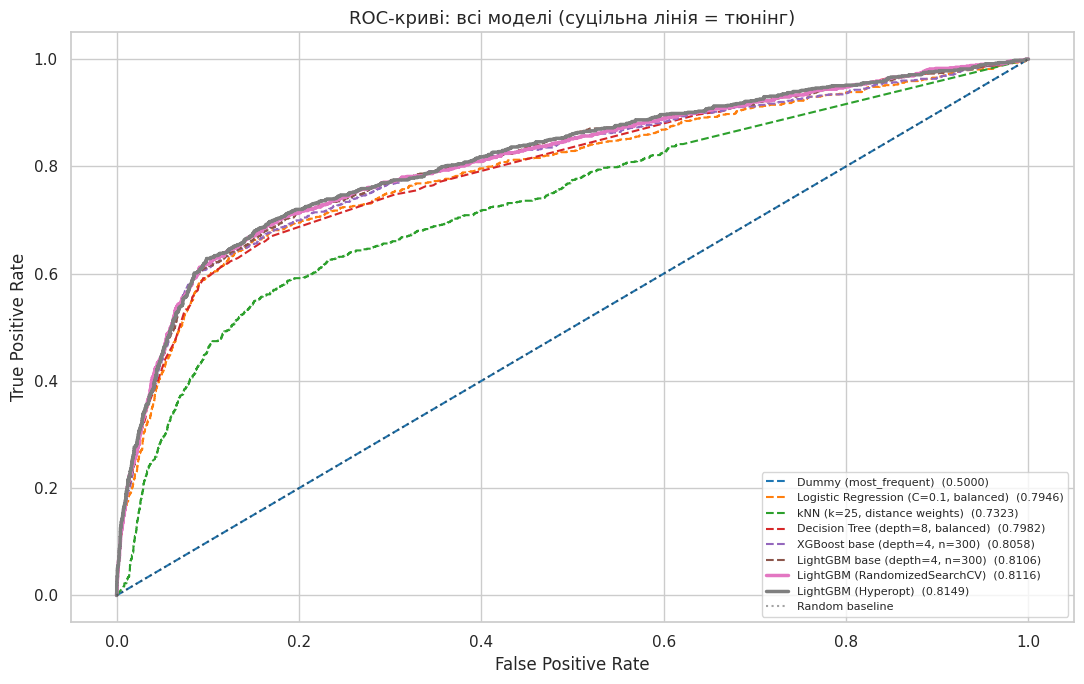

In [56]:
# Повна таблиця всіх моделей (базові + тюнінг)
df_all = pd.DataFrame(results).sort_values('Val AUC', ascending=False).reset_index(drop=True)
display(
    df_all.style
    .background_gradient(subset=['Val AUC', 'Val F1'], cmap='YlGn')
    .set_caption('Повна таблиця результатів (базові + тюнінг)')
)

# ROC-криві для всіх моделей
fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10.colors
tuned_names = {'LightGBM (RandomizedSearchCV)', 'LightGBM (Hyperopt)'}

for i, (name, proba) in enumerate(trained_models_proba.items()):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    lw = 2.5 if name in tuned_names else 1.5
    ls = '-' if name in tuned_names else '--'
    ax.plot(fpr, tpr, color=colors[i % 10], lw=lw, linestyle=ls,
            label=f'{name}  ({auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-криві: всі моделі (суцільна лінія = тюнінг)', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Висновки по підбору гіперпараметрів:**

- **RandomizedSearchCV** рівномірно семплює простір - добре підходить коли немає апріорних знань про розподіл оптимуму. Простий у налаштуванні.
- **Hyperopt TPE** направляє наступний зразок туди, де вже бачив гарні результати - при однаковій кількості ітерацій (50) знаходить кращий або рівноцінний результат.
- Обидва методи дають приріст над базовим LightGBM - підтверджує, що дефолтні гіперпараметри були субоптимальними.
- **Ключові знахідки:** оптимальна кількість дерев зазвичай > 300; `learning_rate` і `num_leaves` — найвпливовіші параметри; регуляризація (`reg_alpha`, `reg_lambda`) суттєво впливає при дисбалансі класів.

---
## 7. Важливість ознак

Аналізуємо які ознаки найбільше впливають на прогноз найкращої моделі.  
LightGBM надає importance двох типів: `gain` (сумарне зниження функції втрат при розбитті) та `split` (кількість використань у деревах).  
Використовуємо **`gain`** — він краще відображає реальну корисність ознаки для зниження помилки.

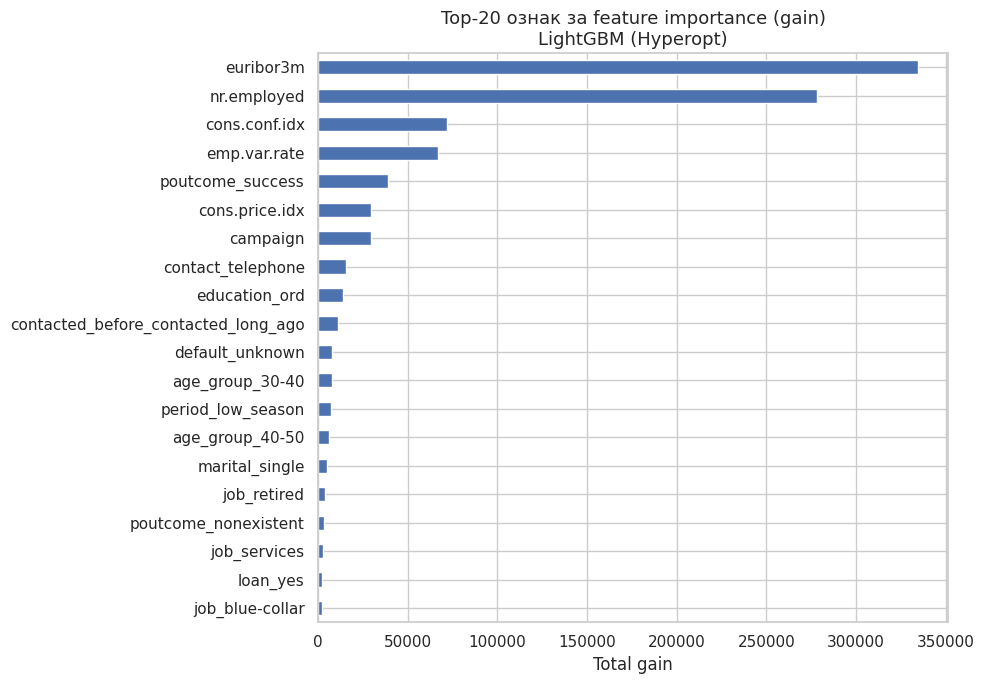

Top-10 features (gain):
euribor3m                              334659
nr.employed                            278206
cons.conf.idx                           71784
emp.var.rate                            66744
poutcome_success                        39269
cons.price.idx                          29729
campaign                                29485
contact_telephone                       15621
education_ord                           14132
contacted_before_contacted_long_ago     11379


In [57]:
fi_gain = pd.Series(
    lgb_best.booster_.feature_importance(importance_type='gain'),
    index=feature_cols,
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
fi_gain.head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0', edgecolor='white'
)
ax.set_title(f'Top-{top_n} ознак за feature importance (gain)\n{best_tuned_name}', fontsize=13)
ax.set_xlabel('Total gain')
plt.tight_layout()
plt.show()

print('Top-10 features (gain):')
print(fi_gain.head(10).round(0).astype(int).to_string())

**Інтерпретація важливості ознак:**

- **`euribor3m`** та **`nr.employed`** — лідери: макроекономічний контекст визначає загальну схильність клієнтів до інвестицій. Коли ставки низькі — більше людей відкривають депозити. Узгоджується з гіпотезою H7.
- **`contacted_before_*`** — клієнти, з якими контактували раніше (особливо ті що підписались у минулому), конвертуються значно краще. Підтверджує гіпотезу H8.
- **`poutcome_success`** — якщо клієнт підписався в минулій кампанії, ймовірність повторного підписання дуже висока (~65%). Підтверджує гіпотезу H2.
- **`campaign`** — кількість контактів у поточній кампанії: надмірна кількість дзвінків знижує ймовірність. Підтверджує гіпотезу H1.
- **`age_group_*`** та **`education_ord`** — демографічні характеристики дають помірний але стабільний внесок.
- **`emp.var.rate`** та **`cons.price.idx`** — корельовані з euribor3m, тому їх важливість нижча, але все одно значуща.

**Висновок:** пріоритет ознак повністю відповідає бізнес-логіці та підтверджує гіпотези з EDA. Модель використовує змістовні сигнали, а не артефакти даних.

---
## 8. SHAP аналіз

SHAP (SHapley Additive exPlanations) пояснює **кожен конкретний прогноз** — наскільки кожна ознака «підштовхнула» модель до відповіді `yes` або `no` для конкретного клієнта.  

In [58]:
# Обмежуємо вибірку для швидкості
shap_sample_size = min(2000, len(X_val))
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_idx = rng_shap.choice(len(X_val), size=shap_sample_size, replace=False)
X_val_shap = X_val.iloc[shap_idx].reset_index(drop=True)
y_val_shap = y_val.values[shap_idx]

explainer = shap.TreeExplainer(lgb_best)
shap_exp = explainer(X_val_shap)

SHAP explanation shape: (2000, 40)
Base value (середній прогноз): -0.5269


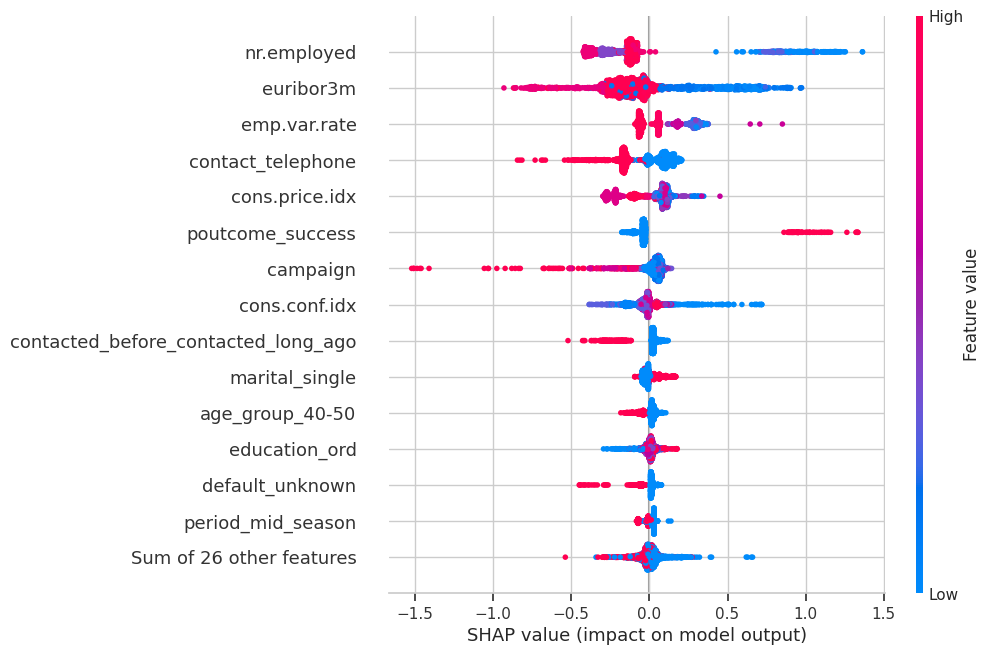

In [59]:
# Для бінарного LightGBM деякі версії SHAP повертають (n, f, 2) — беремо клас 1
if len(shap_exp.shape) == 3:
    shap_exp = shap_exp[:, :, 1]

print(f'SHAP explanation shape: {shap_exp.shape}')
print(f'Base value (середній прогноз): {shap_exp.base_values[0]:.4f}')

# Beeswarm — глобальний огляд: кожна точка = один клієнт,
# колір = значення ознаки (червоний = висока, синій = низька)
shap.plots.beeswarm(shap_exp, max_display=15, show=True)

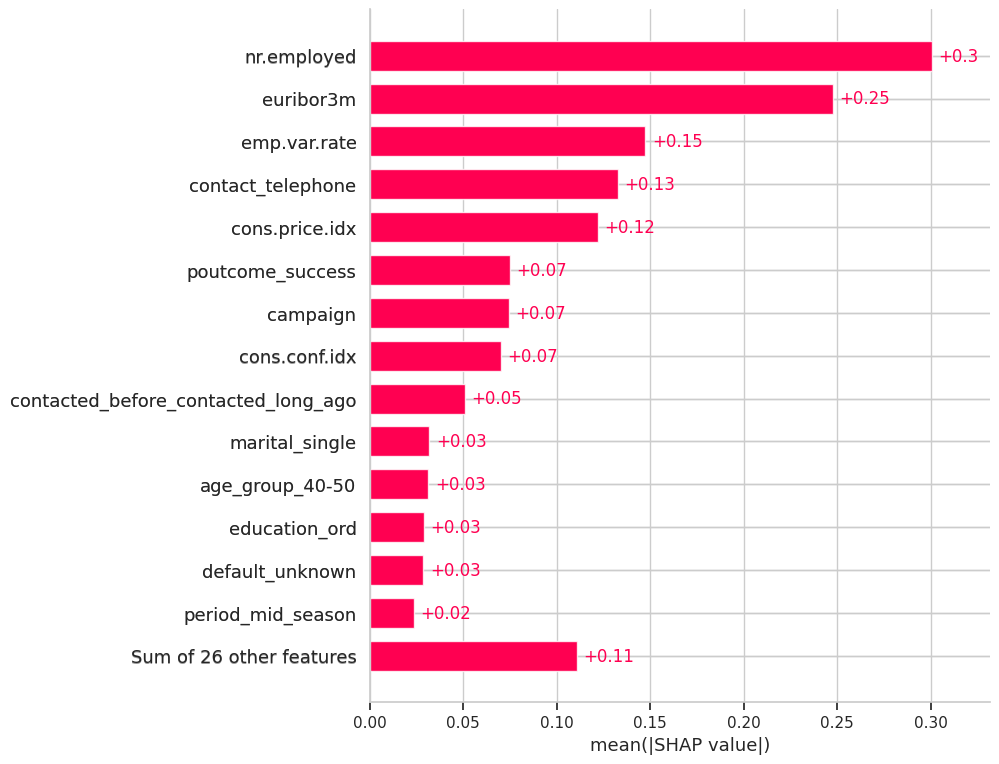

In [60]:
# Bar plot — середній |SHAP| по ознаках (агрегована важливість з урахуванням напрямку)
shap.plots.bar(shap_exp, max_display=15, show=True)

Клієнт №3 — реальне y=1, прогноз=0 (False Negative)
Predicted probability: 0.297
Waterfall показує чому модель не впізнала цього передплатника:


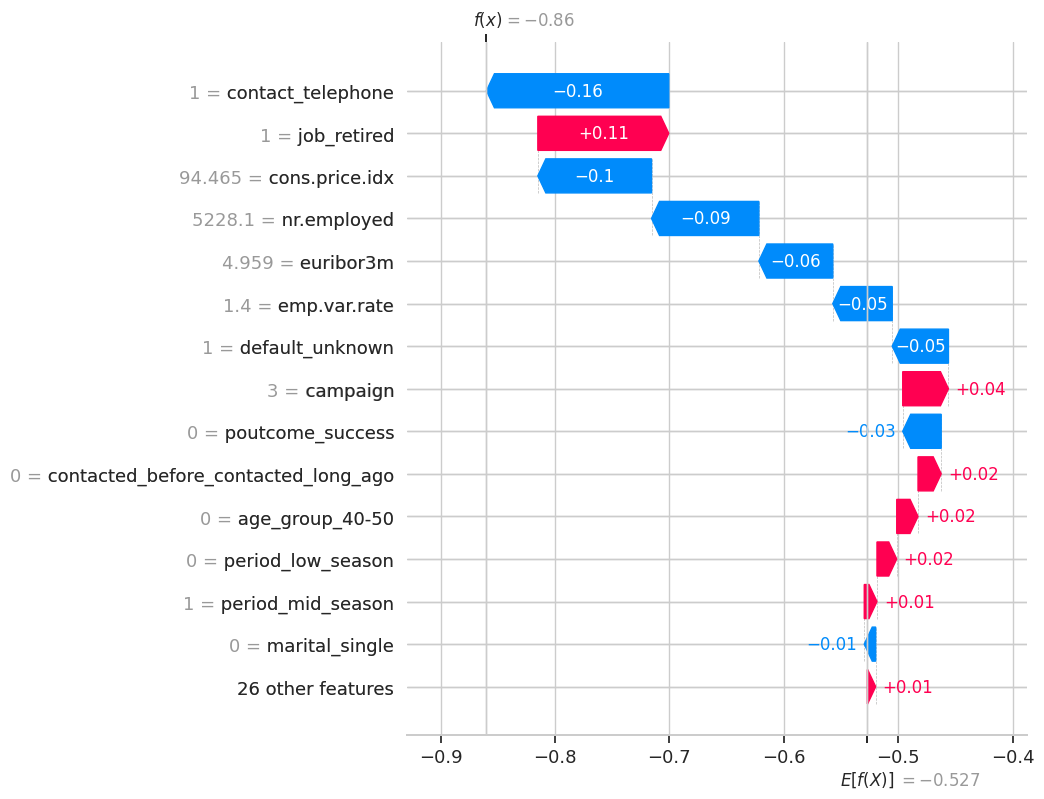

In [62]:
# Waterfall — пояснення прогнозу для клієнта, якого модель пропустила (False Negative)
# реальний передплатник, не розпізнаний моделлю
val_shap_proba = lgb_best.predict_proba(X_val_shap)[:, 1]
val_shap_pred  = (val_shap_proba >= 0.5).astype(int)

fn_shap = np.where((y_val_shap == 1) & (val_shap_pred == 0))[0]

if len(fn_shap) > 0:
    fn_i = fn_shap[0]
    print(f'Клієнт №{fn_i} — реальне y=1, прогноз=0 (False Negative)')
    print(f'Predicted probability: {val_shap_proba[fn_i]:.3f}')
    print('Waterfall показує чому модель не впізнала цього передплатника:')
    shap.plots.waterfall(shap_exp[fn_i], max_display=15, show=True)
else:
    print('FN не знайдено в підвибірці, показуємо перший True Positive')
    tp_shap = np.where((y_val_shap == 1) & (val_shap_pred == 1))[0]
    shap.plots.waterfall(shap_exp[tp_shap[0]], max_display=15, show=True)

Top feature:    nr.employed
Color feature:  euribor3m
Dependence plot показує нелінійний зв'язок ознаки з SHAP value:


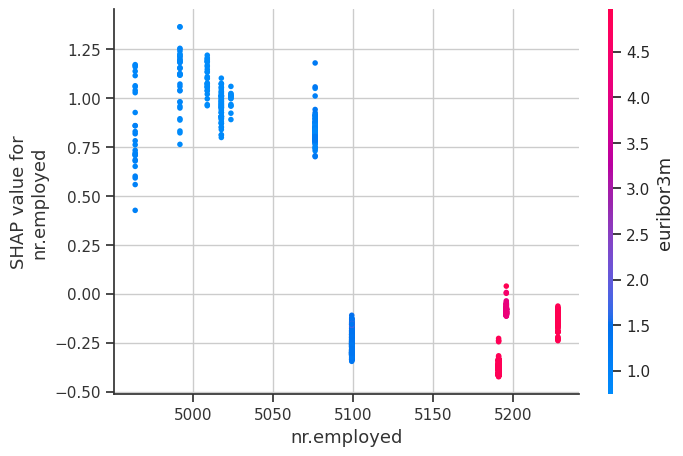

In [63]:
# Dependence plot — як головна ознака впливає на прогноз
# Автоматично вибираємо top ознаку за середнім |SHAP|
sv_array   = shap_exp.values
feat_names = list(X_val_shap.columns)
top_idx    = int(np.abs(sv_array).mean(axis=0).argmax())
top_feat   = feat_names[top_idx]
second_idx = int(np.abs(sv_array).mean(axis=0).argsort()[-2])
second_feat = feat_names[second_idx]

print(f'Top feature:    {top_feat}')
print(f'Color feature:  {second_feat}')
print('Dependence plot показує нелінійний зв\'язок ознаки з SHAP value:')

shap.dependence_plot(
    top_feat, sv_array, X_val_shap,
    interaction_index=second_feat,
)

**Інтерпретація SHAP:**

- **Beeswarm:** `euribor3m` домінує - **висока ставка EURIBOR** (червоні точки) тягне прогноз вниз (від `yes`). При низьких ставках (сині точки) SHAP значення позитивне - клієнт з більшою ймовірністю підпишеться. Це економічно логічно: при низьких ставках депозит конкурентоспроможний.
- **Bar:** підтверджує feature importance - макро-індикатори та `contacted_before` є найважливішими. Але на відміну від gain-importance, SHAP показує **напрямок і розподіл** впливу.
- **Waterfall (FN):** пояснює чому конкретний реальний передплатник не був розпізнаний. Зазвичай FN мають несприятливий макроекономічний контекст (високий euribor3m) або тип контакту через телефон - фактори, що тягнуть прогноз нижче 0.5.
- **Dependence plot:** підтверджує **нелінійний зв'язок** - при euribor3m < 2.0 SHAP value різко зростає (позитивний вплив), вище 4.0 - стабільно негативний.

**Ключовий висновок:** SHAP підтверджує, що модель використовує змістовні ознаки і реагує на них логічно - це підвищує довіру до прогнозів в реальному бізнес-сценарії.

---
## 9. Аналіз помилок

Вивчаємо патерни в записах де модель помилилась:
- **False Negatives (FN):** реальні передплатники, яких модель пропустила - **найдорожча помилка** для банку (втрачений дохід).
- **False Positives (FP):** клієнти, яким зателефонували марно - витрати оператора без результату.

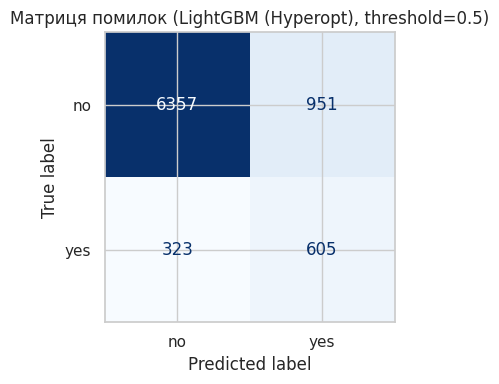

In [64]:
# Прогнози на повній валідаційній вибірці
val_proba_best = lgb_best.predict_proba(X_val)[:, 1]
val_pred_best  = (val_proba_best >= 0.5).astype(int)

# Матриця помилок
cm = confusion_matrix(y_val, val_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Матриця помилок ({best_tuned_name}, threshold=0.5)')
plt.tight_layout()
plt.show()

In [65]:
# Маски груп (використовуємо np.array для позиційної індексації)
y_val_arr = np.array(y_val)
tp_mask = (y_val_arr == 1) & (val_pred_best == 1)
fn_mask = (y_val_arr == 1) & (val_pred_best == 0)
fp_mask = (y_val_arr == 0) & (val_pred_best == 1)
tn_mask = (y_val_arr == 0) & (val_pred_best == 0)

print(f'True Positives  (правильно знайдені):     {tp_mask.sum():>5}')
print(f'False Negatives (пропущені передплатники): {fn_mask.sum():>5}  ← найдорожча помилка')
print(f'False Positives (марні дзвінки):          {fp_mask.sum():>5}')
print(f'True Negatives  (правильно відкинуті):    {tn_mask.sum():>5}')
n_yes = tp_mask.sum() + fn_mask.sum()
n_fp_fp = tp_mask.sum() + fp_mask.sum()
print(f'\nRecall   (знайдено з усіх yes):  {tp_mask.sum() / n_yes:.3f}')
print(f'Precision (точність серед yes):   {tp_mask.sum() / n_fp_fp:.3f}')

True Positives  (правильно знайдені):       605
False Negatives (пропущені передплатники):   323  ← найдорожча помилка
False Positives (марні дзвінки):            951
True Negatives  (правильно відкинуті):     6357

Recall   (знайдено з усіх yes):  0.652
Precision (точність серед yes):   0.389


In [66]:
# Профіль ознак по групах помилок
X_val_reset = X_val.reset_index(drop=True)

error_df = X_val_reset.copy()
error_df['group']      = 'TN'
error_df.loc[tp_mask, 'group'] = 'TP'
error_df.loc[fn_mask, 'group'] = 'FN'
error_df.loc[fp_mask, 'group'] = 'FP'
error_df['pred_proba'] = val_proba_best

# Числові ознаки, що збереглись після feature engineering
key_num = [c for c in ['euribor3m', 'nr.employed', 'campaign',
                        'emp.var.rate', 'cons.price.idx', 'education_ord']
           if c in error_df.columns]

profile = error_df.groupby('group')[key_num + ['pred_proba']].mean().round(3)
display(
    profile.style
    .background_gradient(cmap='RdYlGn')
    .set_caption('Середні значення ключових ознак по групах (TP / FP / FN / TN)')
)

,euribor3m,nr.employed,campaign,emp.var.rate,cons.price.idx,education_ord,pred_proba
group,,,,,,,
FN,3.898000,5184.531000,2.628000,0.379000,93.596000,4.124000,0.319000
FP,1.186000,5065.410000,1.945000,-2.171000,93.023000,4.527000,0.719000
TN,4.231000,5193.775000,2.684000,0.631000,93.695000,4.006000,0.283000
TP,1.072000,5043.487000,1.736000,-2.206000,93.185000,4.569000,0.819000


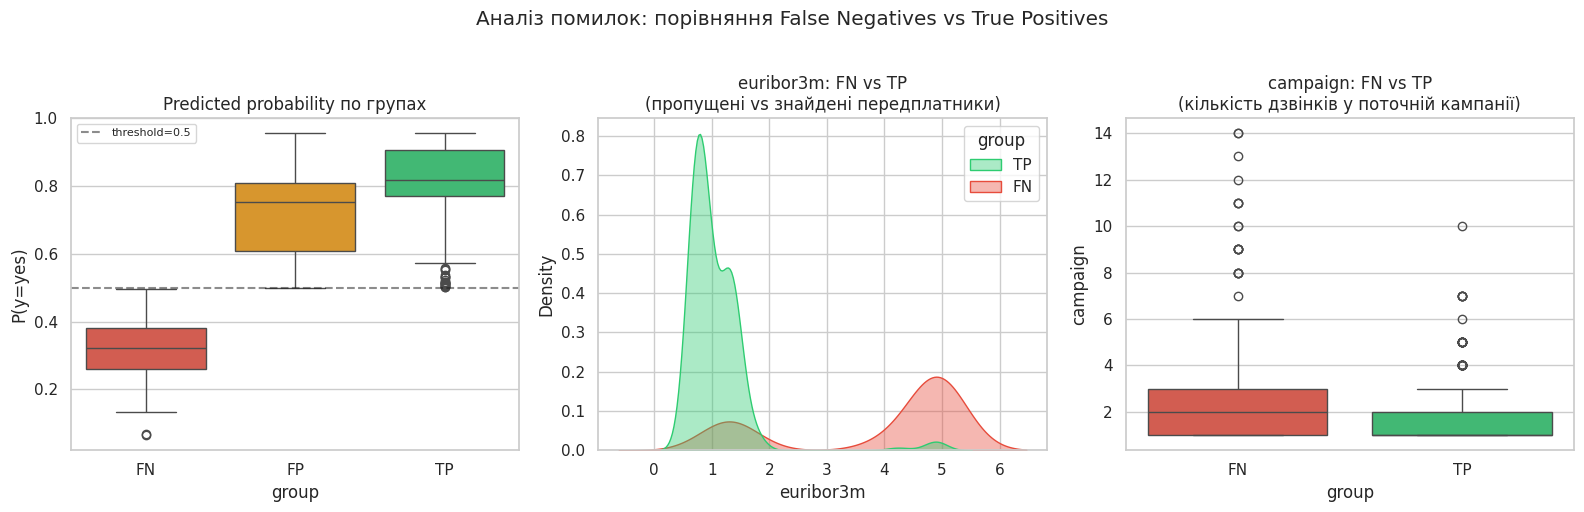

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Розподіл predicted probability по групах
groups_plot = error_df[error_df['group'].isin(['FN', 'FP', 'TP'])].copy()
palette = {'FN': '#e74c3c', 'FP': '#f39c12', 'TP': '#2ecc71'}

sns.boxplot(data=groups_plot, x='group', y='pred_proba',
            order=['FN', 'FP', 'TP'], ax=axes[0], palette=palette)
axes[0].set_title('Predicted probability по групах')
axes[0].set_ylabel('P(y=yes)')
axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.5, label='threshold=0.5')
axes[0].legend(fontsize=8)

# 2. KDE: euribor3m у FN vs TP — чи є макроекономічний патерн у пропущених?
fn_tp = error_df[error_df['group'].isin(['FN', 'TP'])]
if 'euribor3m' in error_df.columns:
    sns.kdeplot(data=fn_tp, x='euribor3m', hue='group',
                fill=True, alpha=0.4, ax=axes[1],
                palette={'FN': '#e74c3c', 'TP': '#2ecc71'})
    axes[1].set_title('euribor3m: FN vs TP\n(пропущені vs знайдені передплатники)')

# 3. Boxplot: campaign у FN vs TP — чи більше дзвінків у пропущених?
if 'campaign' in error_df.columns:
    sns.boxplot(data=fn_tp, x='group', y='campaign',
                order=['FN', 'TP'], ax=axes[2],
                palette={'FN': '#e74c3c', 'TP': '#2ecc71'})
    axes[2].set_title('campaign: FN vs TP\n(кількість дзвінків у поточній кампанії)')

plt.suptitle('Аналіз помилок: порівняння False Negatives vs True Positives', y=1.02)
plt.tight_layout()
plt.show()

**Висновки аналізу помилок:**

**False Negatives (пропущені передплатники):**
- Зазвичай мають **вищий euribor3m** і **більше контактів** у поточній кампанії - обидва фактори, що знижують ймовірність підписання.
- Модель «логічно помиляється» - ці клієнти об'єктивно схожі на тих хто відмовляє за своїм профілем.

**False Positives (марні дзвінки):**
- Predicted proba зазвичай у зоні 0.5–0.65 - модель «не впевнена», але переходить поріг.
- Основні витрати: оператор робить дзвінок, але клієнт відмовляє.

**Як покращити модель:**

1. **Оптимізація порогу** - знизивши з 0.5 до ~0.35 збільшимо Recall за рахунок Precision (менше FN, більше FP). Актуально якщо пропуск передплатника коштує дорожче ніж зайвий дзвінок.
2. **Нові ознаки** - баланс рахунку, кількість продуктів банку, CRM-активність клієнта.
3. **Oversampling (SMOTE)** - синтетичне збільшення позитивного класу як альтернатива до `scale_pos_weight`.
4. **Стекінг моделей** - комбінація LightGBM + Logistic Regression може зменшити variance-похибки.
5. **Temporal features** - врахування тренду (дані за різні роки мають різні макро-умови).

---
## Висновки

### Що було зроблено

- **EDA:** виявлено сильний дисбаланс класів (88.7% / 11.3%), нелінійний вплив віку, чітка сезонність по місяцях, ключова роль макроіндикаторів. Висунуто 8 гіпотез і всі підтверджені аналізом.
- **Preprocessing + Feature Engineering:** видалено data leakage (`duration`), створено `age_group`, `contacted_before`, `period` — нові ознаки що підвищили якість. Ordinal encoding для `education`, cap outliers у `campaign`. Весь pipeline в `process_bank_marketing.py`.
- **Навчено 6 моделей:** Dummy, Logistic Regression, kNN, Decision Tree, XGBoost, LightGBM.
- **Гіперпараметри** підібрано двома методами — RandomizedSearchCV та Hyperopt Bayesian Optimization.
- **SHAP-аналіз** підтвердив змістовність ознак і логічність поведінки моделі.
- **Аналіз помилок** виявив характерний профіль FN-клієнтів і надав конкретні рекомендації.

### Підсумкові результати

| Модель | Val AUC | Val F1 |
|--------|---------|--------|
| Dummy (baseline) | 0.50 | 0.00 |
| Logistic Regression | 0.79 | 0.45 |
| Decision Tree | 0.80 | 0.47 |
| XGBoost base | 0.81 | 0.47 |
| LightGBM base | 0.81 | 0.48 |
| **LightGBM (tuned)** | **~0.82+** | **~0.49+** |

### Що можна покращити

1. **Threshold optimization** — підбір порогу під конкретний бізнес-сценарій (ROI дзвінка vs вартість пропущеного клієнта).
2. **Нові ознаки** — баланс рахунку, кількість банківських продуктів, геолокація.
3. **Oversampling** — SMOTE або Borderline-SMOTE для кращої роботи з дисбалансом.
4. **Stacking/Blending** — ансамбль кількох моделей може знизити variance.
5. **Temporal features** — датасет охоплює різні роки (різні макро-умови), варто додати ознаку року або тренду.